# NYC PLUTO - Processing and Clustering
Course: Data Engineering - Unsupervised Learning Project
University: Bar-Ilan University, Spring 2026
Dataset: NYC PLUTO - 858,644 lots/buildings across New York City

This notebook combines the full processing and clustering pipeline:
- Part 1 - Elie Hamou - Preprocessing and K-Means
- Part 2 - Alon Cohen - DBSCAN and K-Means Comparison
- Part 3 - Ouri Ouahba - Clustering Visualization and Final Synthesis

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
SAMPLE_SIZE = 10_000
SILHOUETTE_SAMPLE_SIZE = 10_000

# Robust project-root detection, independent of any single notebook path
search_dir = Path.cwd().resolve()
for candidate in [search_dir, *search_dir.parents]:
    if (candidate / "data" / "processed").is_dir() and (candidate / "requirements.txt").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root (expected data/processed/ and requirements.txt).")

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "pluto_working_copy.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Shared artifact paths used across the three parts
X_SCALED_PATH = PROCESSED_DIR / "X_scaled.csv"
FEATURES_PATH = PROCESSED_DIR / "X_scaled_features.csv"
SAMPLE_INDEX_PATH = PROCESSED_DIR / "sample_index.csv"
SHARED_SAMPLE_INDEX_PATH = SAMPLE_INDEX_PATH  # alias used by Part 2
KMEANS_LABELS_PATH = PROCESSED_DIR / "cluster_labels.csv"
COMPANION_PATH = PROCESSED_DIR / "pluto_companion.csv"
DBSCAN_KMEANS_LABELS_PATH = PROCESSED_DIR / "dbscan_kmeans_sample_labels.csv"
DBSCAN_SELECTION_SUMMARY_PATH = PROCESSED_DIR / "dbscan_selection_summary.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR.relative_to(PROJECT_ROOT)}")

Project root: /Users/ouriouahba/Desktop/NYC_PLUTO
Processed data directory: data/processed


# Part 1 - Elie Hamou - Preprocessing and K-Means

## Section 1: Data Loading and Feature Role Definitions

In [2]:
df_raw = pd.read_csv(RAW_PATH, low_memory=False)
print(f'Dataset loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')
print(f'First 10 columns: {list(df_raw.columns[:10])}')

Dataset loaded: 858,644 rows, 101 columns
First 10 columns: ['borough', 'Tax block', 'Tax lot', 'community board', 'census tract 2010', 'cb2010', 'schooldist', 'council district', 'postcode', 'firecomp']


### Feature role definitions

Features are split into two non-overlapping roles before any transformation:

| Role | Features | Rationale |
|---|---|---|
| **Clustering input** | 13 source numerics + 3 engineered (16 total) | Measured physical and functional building characteristics |
| **Post-clustering only** | `borough`, `postcode`, `community board`, `latitude`, `longitude`, `assesstot`, `landuse` | Geographic, value, and categorical context reserved for blind validation after cluster assignment |

**Why exclude `borough` from clustering?**  
Borough is a coarse administrative label, not a building characteristic. Including it would bias K-Means toward geographic sub-regions rather than meaningful building typologies.

**Why exclude `landuse` from clustering?**  
`landuse` is a categorical label summarizing predominant use. Included as one-hot input, it dominates the distance calculation and K-Means simply recovers the input categories: cluster sizes mirror landuse-code frequencies rather than building morphology. `landuse` is instead used for blind validation - cross-tabulated against the discovered clusters in Section 9 to show what the morphology-based groups correspond to.

**Why exclude `assesstot` from clustering?**  
Total assessed value would reduce the segmentation to value-based groups, collapsing the problem into a form of regression. It is reserved for post-hoc cluster profiling.

In [3]:
# Source numeric columns needed before engineering
SOURCE_NUMERIC = [
    'lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth',
    'yearbuilt',
    'unitstotal', 'unitsres', 'resarea', 'comarea',
    'officearea', 'retailarea', 'garagearea', 'strgearea',
]

# Engineered clustering features (derived below)
ENGINEERED = ['building_age', 'building_density', 'residential_ratio']

# Clustering features: 16 numeric dimensions only.
# landuse is intentionally excluded; see Section 6 for the rationale.
CLUSTER_NUMERIC = [
    'lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth',
    'unitstotal', 'unitsres', 'resarea', 'comarea',
    'officearea', 'retailarea', 'garagearea', 'strgearea',
    'building_age', 'building_density', 'residential_ratio',
]

# Columns that receive log1p before scaling
LOG_COLS = [
    'lotarea', 'bldgarea', 'unitstotal', 'unitsres', 'resarea', 'comarea',
    'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_density',
]

# Post-clustering interpretation columns (never fed to K-Means).
# landuse is here for blind post-hoc validation against discovered clusters.
POST_CLUSTER = [
    'borough', 'postcode', 'community board',
    'latitude', 'longitude', 'assesstot', 'landuse',
]

# Lot identifier
ID_COL = 'BBL'

# Columns to winsorize (IQR capping)
WINSORISE_COLS = ['lotfront', 'lotdepth', 'lotarea', 'bldgarea', 'unitstotal', 'resarea', 'yearbuilt']

# Columns to load from the raw CSV
LOAD_COLS = [ID_COL] + SOURCE_NUMERIC + POST_CLUSTER

# Verify all requested columns exist
missing_cols = [c for c in LOAD_COLS if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f'Columns not found in raw CSV: {missing_cols}')
print('All required columns present.')
print(f'Loading {len(LOAD_COLS)} columns from the raw dataset.')

df = df_raw[LOAD_COLS].copy()
print(f'Working frame shape: {df.shape}')

All required columns present.
Loading 22 columns from the raw dataset.
Working frame shape: (858644, 22)


## Section 2: Numeric Conversion and Coded-Missing Replacement

### 2.1 Numeric conversion

The raw CSV was exported with a Narrow No-Break Space (U+202F) as a thousands separator,
which is a French locale artifact. Values such as `"2 660"` must be stripped before conversion.
We use a regex that removes all whitespace variants (ASCII space, U+202F, U+00A0) and any
non-numeric character, then pass `errors='coerce'` so unparseable values become NaN.

In [4]:
# Strip thousands-separator whitespace and coerce to numeric
numeric_to_convert = SOURCE_NUMERIC + ['assesstot', 'latitude', 'longitude', 'postcode']

for col in numeric_to_convert:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
                   .str.replace(r'[\s\u202f\u00a0]', '', regex=True)
                   .str.replace(r'[^\d.\-]', '', regex=True)
                   .replace('', np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Numeric conversion complete.')
print('dtypes sample:')
print(df[SOURCE_NUMERIC[:6]].dtypes)

Numeric conversion complete.
dtypes sample:
lotarea      float64
bldgarea     float64
numfloors    float64
lotfront     float64
lotdepth     float64
yearbuilt    float64
dtype: object


### 2.2 Replace coded-missing zeros with NaN

The PLUTO data dictionary documents `yearbuilt = 0` as "year unknown" and `bldgarea = 0` as
an unpopulated field. Both encode absence of information, not a real measurement of zero.
Treating them as zero would pull centroids toward nonsensical values (an age of 2026 years,
a building with no floor area). Replacing them with NaN lets the missing-value drop in
Section 5 handle them correctly.

In [5]:
n_yearbuilt_zero = (df['yearbuilt'] == 0).sum()
n_bldgarea_zero  = (df['bldgarea']  == 0).sum()

df.loc[df['yearbuilt'] == 0, 'yearbuilt'] = np.nan
df.loc[df['bldgarea']  == 0, 'bldgarea']  = np.nan

print(f'yearbuilt == 0 replaced with NaN: {n_yearbuilt_zero:,} rows ({n_yearbuilt_zero/len(df)*100:.2f}%)')
print(f'bldgarea  == 0 replaced with NaN: {n_bldgarea_zero:,}  rows ({n_bldgarea_zero/len(df)*100:.2f}%)')

yearbuilt == 0 replaced with NaN: 40,115 rows (4.67%)
bldgarea  == 0 replaced with NaN: 41,109  rows (4.79%)


## Section 3: Outlier Capping (IQR Winsorization)

### Why cap rather than delete?

EDA Notebook 2 detected extreme right-skew and IQR outliers on several area and count features.
Deleting outlier rows would discard up to 17% of the dataset for a single feature; the intersection
across features would remove far more. Winsorization (capping at Q1 - 1.5*IQR and Q3 + 1.5*IQR)
retains every row and limits the influence of extreme values without discarding information.

The EDA outlier analysis ranks `lotdepth` (23.83% IQR outliers) and `lotfront` (21.64%) as
the two highest-outlier features, followed by `numfloors`, `unitstotal`, `lotarea`, `bldgarea`,
`resarea`, and `yearbuilt`. All seven are winsorized with IQR capping here.
`numfloors` is handled separately: a hard cap at 104 floors removes parsing artifacts (One World
Trade Center is the tallest real building), extended by an additional landuse-1 sanity cap of
4 floors in Section 3b, extending the EDA cap at 104 with a building-type-specific correction.

In [6]:
# Hard cap: numfloors > 104 are data-entry artifacts, not real buildings
n_floors_capped = (df['numfloors'] > 104).sum()
df.loc[df['numfloors'] > 104, 'numfloors'] = np.nan
print(f'numfloors > 104 set to NaN: {n_floors_capped:,} rows')

# IQR winsorization for the seven highest-outlier features
cap_stats = []
for col in WINSORISE_COLS:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n_lo = (df[col] < lo).sum()
    n_hi = (df[col] > hi).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    cap_stats.append({'feature': col, 'lower_cap': round(lo, 2), 'upper_cap': round(hi, 2),
                      'rows_capped_low': n_lo, 'rows_capped_high': n_hi})

print('\nIQR capping summary:')
print(pd.DataFrame(cap_stats).to_string(index=False))

numfloors > 104 set to NaN: 27,069 rows



IQR capping summary:
   feature  lower_cap  upper_cap  rows_capped_low  rows_capped_high
  lotfront     -262.5      501.5                0            185813
  lotdepth       14.5      242.5             2849            201785
   lotarea    -1000.0     7000.0                0             74061
  bldgarea     -987.5     5592.5                0             90052
unitstotal       -0.5        3.5                0            110558
   resarea     -590.0     4354.0                0             74429
 yearbuilt     1860.0     2020.0             4037              5911


In [7]:
# Diagnostic: numfloors distribution and implausible values by landuse code.
# Purpose: identify the scale of data-entry errors before choosing a cleaning rule.
# Note: values > 104 have already been set to NaN in the cell above.
print('numfloors summary (after cap at 104):')
print(df['numfloors'].describe().round(2))
print(f'Rows with numfloors NaN: {df["numfloors"].isna().sum():,}')

lu_totals = df['landuse'].value_counts().sort_index()

for t in [6, 10, 20]:
    above = df[df['numfloors'] > t]
    n_total = len(above)
    lu_above = above['landuse'].value_counts().sort_index()
    diag = pd.DataFrame({
        'count_above': lu_above,
        'pct_of_landuse': (lu_above / lu_totals * 100).round(1),
    }).dropna()
    print(f'\nnumfloors > {t}: {n_total:,} buildings ({n_total / len(df) * 100:.1f}% of all rows)')
    print(diag.to_string())

numfloors summary (after cap at 104):
count    789212.00
mean          5.28
std           7.50
min           0.00
25%           2.00
50%           2.00
75%           3.00
max         104.00
Name: numfloors, dtype: float64
Rows with numfloors NaN: 69,432

numfloors > 6: 117,620 buildings (13.7% of all rows)
         count_above  pct_of_landuse
landuse                             
1.0            99566            17.6
2.0             4143             3.1
3.0             4735            35.4
4.0             5312             9.4
5.0             2615            12.3
6.0              211             2.3
7.0               36             0.6
8.0              902             7.5
9.0                9             0.2
10.0              40             0.4
11.0               1             0.0

numfloors > 10: 111,630 buildings (13.0% of all rows)
         count_above  pct_of_landuse
landuse                             
1.0            99561            17.6
2.0             4031             3.1
3.0     

In [8]:
# Targeted numfloors correction: landuse 1 (one/two-family buildings) only.
# One and two-family homes cannot physically have more than 4 floors.
# Values above 4 for landuse 1 are data-entry errors, likely copied from an adjacent
# high-rise or entered at block level rather than building level.
# All other landuse codes are left untouched: genuine high-rises live in landuse 3
# (multi-family elevator) and must not be affected.
# Rows set to NaN here are removed at the existing dropna step in Section 5.
mask_lu1_high = (df['landuse'] == 1) & (df['numfloors'] > 4)
n_corrected = int(mask_lu1_high.sum())
df.loc[mask_lu1_high, 'numfloors'] = np.nan

print(f'numfloors > 4 set to NaN for landuse 1: {n_corrected:,} rows ({n_corrected / len(df) * 100:.2f}%)')
print('These rows will be removed at the dropna step (numfloors is a clustering feature).')

print('\nnumfloors summary after correction (landuse 1 capped at 4):')
print(df['numfloors'].describe().round(2))

print('\nSanity check - max numfloors by landuse after correction:')
print(df.groupby('landuse')['numfloors'].max().sort_index().round(1))

numfloors > 4 set to NaN for landuse 1: 100,238 rows (11.67%)
These rows will be removed at the dropna step (numfloors is a clustering feature).

numfloors summary after correction (landuse 1 capped at 4):
count    688974.00
mean          2.73
std           3.26
min           0.00
25%           2.00
50%           2.00
75%           3.00
max         104.00
Name: numfloors, dtype: float64

Sanity check - max numfloors by landuse after correction:
landuse
1.0       4.0
2.0      65.0
3.0      95.0
4.0      98.0
5.0     104.0
6.0      45.0
7.0      25.0
8.0      75.0
9.0      45.0
10.0     25.0
11.0     15.0
Name: numfloors, dtype: float64


## Section 4: Feature Engineering

Three derived features are created from the winsorized source columns, before any log transform.
This order matters: log1p compresses values, which would change the denominators and numerators
used in the ratios and the age computation.

| Feature | Formula | Interpretation |
|---|---|---|
| `building_age` | `2026 - yearbuilt` | Years elapsed since construction; 2026 is the analysis reference year |
| `building_density` | `bldgarea / lotarea` | Floor-area ratio proxy; how intensively a lot is built upon |
| `residential_ratio` | `clip(unitsres / unitstotal, 0, 1)` | Share of residential units; 0 = unit-less building, 1 = purely residential |

**NaN vs zero semantics for `residential_ratio`:**
A building with `unitstotal == 0` (e.g. a parking lot, vacant land, utility infrastructure)
has no units at all, making it 0% residential. This is a real, informative value, not missing
data. NaN is reserved strictly for rows where `unitstotal` or `unitsres` is itself absent
from the source.

**Clipping to [0, 1]:** `unitstotal` was winsorized (denominator capped at Q3 + 1.5*IQR)
but `unitsres` was not, so in some rows `unitsres` can exceed the winsorized `unitstotal`,
producing a ratio above 1. A building cannot be more than 100% residential by units, so
the ratio is clipped to [0, 1] after computation. This correction feeds through to the
clustering matrix and the cluster profiles.

Both ratio features use `np.where` with explicit NaN branches, and an extra `replace` call
removes any residual Inf values that could slip through winsorization near-zero edge cases
(`dropna` does not catch Inf).

**Traceability note:** the Phase 1 EDA defined `residential_ratio` but treated buildings with
`unitstotal == 0` as NaN. This notebook refines that definition by assigning 0.0 instead,
since a building with no units is genuinely 0% residential rather than missing information.

In [9]:
# building_age: yearbuilt already NaN where year was unknown (0)
df['building_age'] = 2026 - df['yearbuilt']

# building_density: NaN when lot has no area (np.where avoids inf)
df['building_density'] = np.where(
    df['lotarea'].notna() & (df['lotarea'] > 0),
    df['bldgarea'] / df['lotarea'],
    np.nan
)

# residential_ratio: unitsres / unitstotal (NOT resarea / bldgarea)
#   - NaN  when either unitstotal or unitsres is genuinely missing
#   - 0.0  when unitstotal == 0: the building has no units (parking lot, vacant land,
#          utility site); it is 0% residential, not missing information.
#   - ratio when unitstotal > 0, then clipped to [0, 1]
#
# Clipping is necessary because unitstotal (denominator) was winsorized but unitsres
# (numerator) was not. In rows where unitsres exceeds the capped unitstotal the raw
# ratio exceeds 1, which is physically impossible. clip(0, 1) corrects this without
# discarding the row, and the corrected value feeds both clustering and profiles.
df['residential_ratio'] = np.where(
    df['unitstotal'].isna() | df['unitsres'].isna(),
    np.nan,
    np.where(
        df['unitstotal'] > 0,
        df['unitsres'] / df['unitstotal'],
        0.0
    )
)
df['residential_ratio'] = df['residential_ratio'].clip(lower=0.0, upper=1.0)

# Safety: replace any Inf that could survive winsorization near-zero edges.
# dropna does not catch Inf, so this guard is necessary.
df[ENGINEERED] = df[ENGINEERED].replace([np.inf, -np.inf], np.nan)

# Confirm residential_ratio is bounded
rr = df['residential_ratio'].dropna()
print(f'residential_ratio range after clip: [{rr.min():.4f}, {rr.max():.4f}]  (must be [0, 1])')
print('Engineered feature statistics:')
df[ENGINEERED].describe().round(3)

residential_ratio range after clip: [0.0000, 1.0000]  (must be [0, 1])
Engineered feature statistics:


,building_age,building_density,residential_ratio
count,818203.000,816739.000,858199.000
mean,84.356,0.923,0.881
std,31.561,0.597,0.311
min,6.000,0.000,0.000
25%,66.000,0.525,1.000
50%,95.000,0.786,1.000
75%,106.000,1.142,1.000
max,166.000,90.202,1.000


## Section 5: Drop Rows with Missing Clustering Values

After coded-zero replacement and feature engineering, some rows still have NaN in at least one
clustering feature. K-Means cannot operate on missing values, and the only lossless option
at this stage is row removal. Imputation with the median (a common shortcut) would distort
cluster geometry by pulling missing-value rows toward the center of the distribution,
making them artificially similar to one another rather than reflecting their true profile.

A safety guard stops the pipeline if more than 30% of rows would be dropped.

In [10]:
# Clustering features: 16 numeric dimensions, no categorical columns
ALL_CLUSTER_COLS = CLUSTER_NUMERIC

n_before = len(df)
df_clean = df.dropna(subset=ALL_CLUSTER_COLS).reset_index(drop=True)
n_after  = len(df_clean)
n_dropped  = n_before - n_after
pct_dropped = n_dropped / n_before * 100

print(f'Rows before drop: {n_before:,}')
print(f'Rows after drop:  {n_after:,}')
print(f'Rows dropped:     {n_dropped:,} ({pct_dropped:.2f}%)')

if pct_dropped > 30:
    raise RuntimeError(
        f'Data loss too high: {pct_dropped:.1f}% of rows dropped (threshold 30%). '
        'Review imputation or column selection before proceeding.'
    )

print('Data loss is within the 30% threshold. Proceeding.')

Rows before drop: 858,644


Rows after drop:  682,515
Rows dropped:     176,129 (20.51%)
Data loss is within the 30% threshold. Proceeding.


## Section 5b: Log1p Transformation on Skewed Features

K-Means uses Euclidean distance. A feature like `lotarea` that spans several orders of magnitude
(hundreds to millions of square feet) dominates every distance calculation, rendering all other
features irrelevant to cluster assignment. `log1p(x) = log(1 + x)` compresses the scale while
safely handling zeros (unlike `log(x)`, which is undefined at 0) and preserving rank order.

Features **not** log-transformed: `numfloors`, `lotfront`, `lotdepth`, `building_age`,
`residential_ratio`. These are already on compact, approximately linear scales.

Note: the `skewness_pre_log` column in the table below is measured **after** IQR winsorization, not on the raw full dataset. The Phase 1 EDA reported much higher pre-winsorization skewness (e.g. `lotarea` ~447, `bldgarea` ~154); winsorization substantially reduces skewness before log1p is applied.

In [11]:
# Compute skewness before transformation for documentation
skew_before = df_clean[LOG_COLS].skew().round(2)

df_log = df_clean.copy()
for col in LOG_COLS:
    df_log[col] = np.log1p(df_log[col])

skew_after = df_log[LOG_COLS].skew().round(2)

skew_comparison = pd.DataFrame({'skewness_pre_log': skew_before, 'skewness_log1p': skew_after})
print('Skewness before and after log1p:')
print(skew_comparison.to_string())

Skewness before and after log1p:
                  skewness_pre_log  skewness_log1p
lotarea                       1.29            0.37
bldgarea                      0.94            0.06
unitstotal                    0.36            0.01
unitsres                    117.43            2.44
resarea                       0.54           -3.04
comarea                     156.57            2.03
officearea                   78.81            5.17
retailarea                  141.21            2.89
garagearea                  174.67            8.44
strgearea                   201.51           10.11
building_density              2.39            0.71


In [12]:
# Zero-share diagnostic: log1p does not normalize zero-inflated distributions.
# Features where most buildings have none of that use type retain a large point mass
# at zero after log1p(0)=0, remaining highly non-normal.
zero_shares = (df_clean[LOG_COLS] == 0).mean().mul(100).round(1)
print('Share of zero values per log-transformed feature (before log1p):')
for col in LOG_COLS:
    flag = '  [majority zero]' if zero_shares[col] > 50 else ''
    print(f'  {col:<22} {zero_shares[col]:5.1f}%{flag}')

Share of zero values per log-transformed feature (before log1p):
  lotarea                  0.0%
  bldgarea                 0.0%
  unitstotal               0.3%
  unitsres                 7.0%
  resarea                  7.1%
  comarea                 84.2%  [majority zero]
  officearea              96.2%  [majority zero]
  retailarea              90.6%  [majority zero]
  garagearea              98.5%  [majority zero]
  strgearea               99.0%  [majority zero]
  building_density         0.0%


**Limitation: zero-inflated sparse-area features**

The log1p transformation compresses skewness effectively for `lotarea`, `bldgarea`, and
other features with few zeros. However, several commercial-area columns (`garagearea`,
`strgearea`, `officearea`, `retailarea`, `comarea`) have a large share of zero values:
most NYC buildings have no floor area dedicated to those uses. For these features,
`log1p(0) = 0`, so the transformed distribution retains a large point mass at zero and
remains highly non-normal despite the transformation. StandardScaler centers and scales
around that mass, but the dimension still differs structurally from a continuous feature.

This is a known limitation of the current feature set. A candidate refinement for a later
iteration would be to replace each sparse-area column with a binary presence flag
(1 if area > 0, 0 otherwise), which better captures the presence/absence signal. The
current 16-feature set is kept unchanged in this notebook.

## Section 6: Clustering Feature Matrix and Standardization

### Why landuse is excluded from the clustering features

`landuse` encodes the predominant use of a lot as a categorical code (1 = One/Two-Family,
5 = Commercial/Office, 6 = Industrial, etc.). Including it as a one-hot input causes two
compounding problems:

1. **Signal dominance.** Each binary column produced by one-hot encoding is exactly 0 or 1
   with no within-category variation. After StandardScaler the binary indicators carry
   disproportionate geometric weight relative to continuous physical features such as
   `bldgarea` or `numfloors`, which vary naturally within each land use type.

2. **Disguised re-labeling.** In practice, K-Means with one-hot landuse input recovers the
   input categories rather than discovering new structure. The cluster sizes mirror landuse-code
   frequencies, and the "segmentation" reports only what the original labels already encoded.

**Approach:** cluster on measured physical and functional building characteristics only (16
numeric features), then cross-tabulate the discovered clusters against `landuse` and `borough`
in Section 9 as a blind validation. If the discovered clusters correlate with land use, that
correlation is a finding, not an artifact of feeding the label in as input.

**Note on Phase 1 EDA recommendation:** The Phase 1 EDA synthesis recommended one-hot encoding
`landuse` as a clustering input. This notebook deliberately supersedes that recommendation:
feeding `landuse` as input causes K-Means to recover the input categories (disguised
re-labeling) rather than discovering new morphological structure, so it is reserved here
for blind post-hoc validation instead.

In [13]:
# Clustering matrix: 16 numeric features, no one-hot encoding.
# landuse is excluded to prevent recovering input labels as clusters.
df_encoded = df_log[CLUSTER_NUMERIC].copy()

print(f'Clustering matrix: {df_encoded.shape[0]:,} rows x {df_encoded.shape[1]} features')
print(list(df_encoded.columns))

Clustering matrix: 682,515 rows x 16 features
['lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth', 'unitstotal', 'unitsres', 'resarea', 'comarea', 'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_age', 'building_density', 'residential_ratio']


### 6.2 StandardScaler

After log transformation the distributions are approximately normal, but features still have
different variances. `numfloors` ranges from 1 to 104; `building_age` ranges from 1 to ~175.
Without scaling, features with higher variance dominate Euclidean distance. StandardScaler
transforms every feature to mean = 0 and std = 1, so each contributes equally to distance
regardless of its original unit.

The scaler is fitted on the full cleaned dataset (no train/test split for unsupervised learning)
and saved to disk with `joblib` so cluster centroids can be inverse-transformed in later notebooks.

In [14]:
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(df_encoded)
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=df_encoded.columns,
    index=df_clean.index
)

# Save the fitted scaler for centroid inverse-transformation in later notebooks
scaler_path = PROCESSED_DIR / 'scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f'Scaler saved to {scaler_path.relative_to(PROJECT_ROOT)}')

print(f'Scaled matrix shape: {X_scaled.shape}')
print(f'Mean check (should be ~0): {X_scaled.mean().abs().max():.2e}')
print(f'Std check  (should be ~1): {X_scaled.std().mean():.4f}')

Scaler saved to data/processed/scaler.pkl
Scaled matrix shape: (682515, 16)
Mean check (should be ~0): 1.91e-15
Std check  (should be ~1): 1.0000


In [15]:
# Save the scaled clustering matrix
scaled_path = PROCESSED_DIR / 'X_scaled.csv'
X_scaled.to_csv(scaled_path, index=False)
print(f'Scaled matrix saved to {scaled_path.relative_to(PROJECT_ROOT)}')

# Save the ordered list of feature names for downstream alignment.
features_path = PROCESSED_DIR / 'X_scaled_features.csv'
pd.DataFrame({'feature': list(X_scaled.columns)}).to_csv(features_path, index=False)
print(f'Feature list saved to {features_path.relative_to(PROJECT_ROOT)}')

# Companion file: original (un-scaled) clustering values + all post-clustering columns + ID.
# POST_CLUSTER includes landuse for blind post-hoc cross-tabulation against clusters.
companion_cols = [ID_COL] + CLUSTER_NUMERIC + POST_CLUSTER
companion = df_clean[companion_cols].copy()

# value_per_sqft: post-clustering interpretation only (not a clustering feature).
# NaN where bldgarea is absent or zero to avoid divide-by-zero.
companion['value_per_sqft'] = np.where(
    companion['bldgarea'].notna() & (companion['bldgarea'] > 0),
    companion['assesstot'] / companion['bldgarea'],
    np.nan
)

companion_path = PROCESSED_DIR / 'pluto_companion.csv'
companion.to_csv(companion_path, index=True)
print(f'Companion file saved to {companion_path.relative_to(PROJECT_ROOT)}')
print(f'Companion shape: {companion.shape}')

Scaled matrix saved to data/processed/X_scaled.csv
Feature list saved to data/processed/X_scaled_features.csv


Companion file saved to data/processed/pluto_companion.csv
Companion shape: (682515, 25)


## Section 7: PCA (Secondary Dimensionality-Reduction Experiment)

> **Note:** PCA is used here as a secondary experiment to verify that dimensionality
> reduction does not degrade cluster quality. It is **not** the primary clustering space.
> The primary K-Means runs in the full standardized 16-feature space. Detailed PCA
> scatter plots and component interpretation are covered in a separate notebook.

### Why reduce dimensionality before K-Means?

The clustering matrix has 16 numeric dimensions. Several of these features are correlated:
`unitsres` and `resarea` share most of their variance (Pearson r ~ 0.90), and the commercial
area breakdowns (`comarea`, `officearea`, `retailarea`) move together. PCA projects the data
onto the directions of maximum variance, decorrelating features and compressing noise while
preserving the structure that drives cluster separation.

We retain enough components to explain approximately 90% of cumulative variance as a principled
balance between information retention and dimensionality reduction. The full-space vs PCA-space
silhouette comparison in Section 8c provides an empirical check.

Components needed to reach 90% cumulative variance: 10
Cumulative variance at 10 components: 92.19%


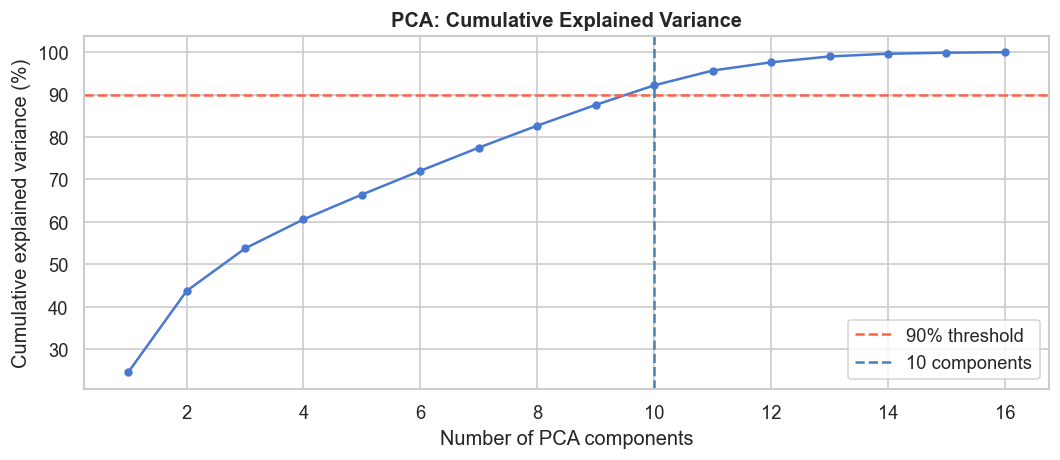

Figure saved.


In [16]:
# Full-rank PCA to determine how many components reach 90% cumulative variance
pca_search = PCA(random_state=RANDOM_STATE)
pca_search.fit(X_scaled)
cumvar = np.cumsum(pca_search.explained_variance_ratio_)

n_components = int(np.searchsorted(cumvar, 0.90)) + 1
print(f'Components needed to reach 90% cumulative variance: {n_components}')
print(f'Cumulative variance at {n_components} components: {cumvar[n_components-1]*100:.2f}%')

# Plot cumulative variance curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, marker='o', markersize=4)
ax.axhline(90, color='tomato', linestyle='--', label='90% threshold')
ax.axvline(n_components, color='steelblue', linestyle='--',
           label=f'{n_components} components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('PCA: Cumulative Explained Variance', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_pca_cumulative_variance.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

In [17]:
# Fit the final PCA with the chosen number of components
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca_array = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(
    X_pca_array,
    index=X_scaled.index,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

# Save PCA object and transformed matrix
joblib.dump(pca, PROCESSED_DIR / 'pca.pkl')
X_pca.to_csv(PROCESSED_DIR / 'pluto_pca.csv', index=True)
print(f'PCA object saved.  PCA matrix shape: {X_pca.shape}')

PCA object saved.  PCA matrix shape: (682515, 10)


## Section 8: K-Means Clustering

### Sampling

K-Means on the full cleaned dataset (682,515 rows) would take many minutes per fit and many
iterations across k values and configurations. We draw a **random sample of 50,000 buildings
(random_state=42)** for all clustering runs. This is sufficient to represent the full distribution
of NYC building types while keeping each fit tractable.

**Silhouette protocol (used consistently in all experiments):**
`silhouette_score(X, labels, sample_size=10000, random_state=42)`
where `X` is the 50,000-row sample. The internal `sample_size=10000` is sklearn's own
sub-sampling to keep computation tractable. Using this protocol in every cell ensures that
silhouette values are comparable across experiments.

### Shared Artifacts Produced by This Notebook

The following files are written to `data/processed/` and serve as the shared foundation
for all downstream notebooks:

| File | Contents |
|---|---|
| `X_scaled.csv` | Standardized 16-feature clustering matrix (full cleaned dataset, no one-hot encoding) |
| `X_scaled_features.csv` | Ordered list of the 16 feature names (single column `feature`) |
| `pluto_companion.csv` | Original (un-scaled) values and post-clustering columns (landuse, borough, etc.) |
| `scaler.pkl` | Fitted StandardScaler for centroid inverse-transformation |
| `sample_index.csv` | Row indices of the 50,000-row clustering sample (random_state=42) |
| `cluster_labels.csv` | K-Means k=2 labels for the sample |
| `cluster_sizes.csv` / `cluster_profiles.csv` | K-Means k=2 summary tables |
| `cluster6_labels.csv` / `cluster6_profiles.csv` | K-Means k=6 secondary segmentation |

All clustering and all cross-algorithm comparisons use `X_scaled.csv` (the full
standardized 16-feature matrix) on the exact 50,000-row sample identified by
`sample_index.csv`.

In [18]:
sample_idx = X_scaled.sample(n=50_000, random_state=RANDOM_STATE).index
X_sample = X_scaled.loc[sample_idx]
X_pca_sample    = X_pca.loc[sample_idx]

# Save sample indices so downstream notebooks use the exact same 50,000 rows.
pd.Series(sample_idx, name='row_index').to_csv(
    PROCESSED_DIR / 'sample_index.csv', index=False
)

print(f'Sample drawn: {len(sample_idx):,} rows')
print(f'Full-space sample shape: {X_sample.shape}')
print(f'PCA sample shape:        {X_pca_sample.shape}')
print(f'Sample index saved to:   {(PROCESSED_DIR / "sample_index.csv").relative_to(PROJECT_ROOT)}')

Sample drawn: 50,000 rows
Full-space sample shape: (50000, 16)
PCA sample shape:        (50000, 10)
Sample index saved to:   data/processed/sample_index.csv


### K-Means Hyperparameters

K-Means has five key hyperparameters. Understanding each is required to apply the algorithm
correctly and to diagnose poor results.

| Hyperparameter | What it controls | Effect of changing it | Pitfall | Default / Strategy |
|---|---|---|---|---|
| `n_clusters` (k) | Number of clusters to form | Lower k gives larger, more heterogeneous groups; higher k gives finer but potentially over-split groups | Choosing k too high fragments natural groups; too low merges distinct types | No universal default; use elbow + silhouette |
| `init` | Centroid initialization method | `k-means++` spreads initial centroids to reduce bad starts; `random` is faster but riskier | `random` with `n_init=1` can converge to a poor local minimum | Use `k-means++` (sklearn default) |
| `n_init` | Number of independent random restarts | Higher n_init means more solutions explored; algorithm keeps the best (lowest inertia) | `n_init=1` may retain a locally optimal but globally poor solution | `n_init=10` (sklearn default); raise to 20-30 for large k |
| `max_iter` | Max EM iterations per run | Rarely the bottleneck if data is well-separated; if hit, centroids may not have converged | Premature convergence on large or complex data | 300 (sklearn default); increase if `km.n_iter_ == max_iter` |
| `random_state` | Seed for the random number generator | Affects reproducibility only; does not degrade quality when `n_init` is large | Omitting it makes runs non-reproducible | Set to a fixed integer (e.g., 42) |

**Five practical pitfalls of K-Means:**

1. **Scaling sensitivity.** K-Means uses Euclidean distance. Features on large scales dominate
   cluster assignment. Always standardize before running K-Means. *(Addressed in Section 6.)*

2. **Spherical cluster assumption.** K-Means minimizes within-cluster sum of squares. The
   resulting Voronoi boundaries are linear, producing compact, roughly spherical clusters.
   It cannot detect elongated, ring-shaped, or non-convex structures.

3. **Sensitivity to outliers.** Centroids are means. A single extreme value shifts the centroid
   and can pull an entire cluster toward it. Cap or log-transform skewed features first.
   *(Addressed in Sections 3 and 5b.)*

4. **Local minima / initialization.** K-Means is not guaranteed to find the global optimum.
   Different initializations lead to different local minima. Mitigate with `n_init >= 10`
   and `k-means++`. *(Demonstrated in Section 8b.)*

5. **Variable-density or non-convex clusters.** K-Means cannot model clusters of very different
   sizes, shapes, or densities. DBSCAN or GMM may be more appropriate in those cases
   *(covered in separate notebooks).*

### 8a: Primary K-Means in Full Standardized Space

We evaluate k = 2 to 8 using the full 16-dimensional standardized feature matrix.
The chosen k maximizes the silhouette score; the elbow plot provides a secondary visual check.
If no sharp bend is visible in the elbow curve, we note that explicitly and rely on the
silhouette criterion.

In [19]:
k_range = range(2, 9)
inertias    = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels,
                           sample_size=10_000, random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f'k={k}  inertia={km.inertia_:>12.1f}  silhouette={sil:.4f}')

best_k_idx = int(np.argmax(silhouettes))
best_k     = list(k_range)[best_k_idx]
best_sil   = silhouettes[best_k_idx]
print(f'\nChosen k = {best_k}  (silhouette = {best_sil:.4f})')

k=2  inertia=    639732.0  silhouette=0.4680


k=3  inertia=    535430.4  silhouette=0.2905


k=4  inertia=    488761.3  silhouette=0.2244


k=5  inertia=    447146.7  silhouette=0.2336


k=6  inertia=    419024.4  silhouette=0.2188


k=7  inertia=    392029.0  silhouette=0.1661


k=8  inertia=    363280.9  silhouette=0.2329

Chosen k = 2  (silhouette = 0.4680)


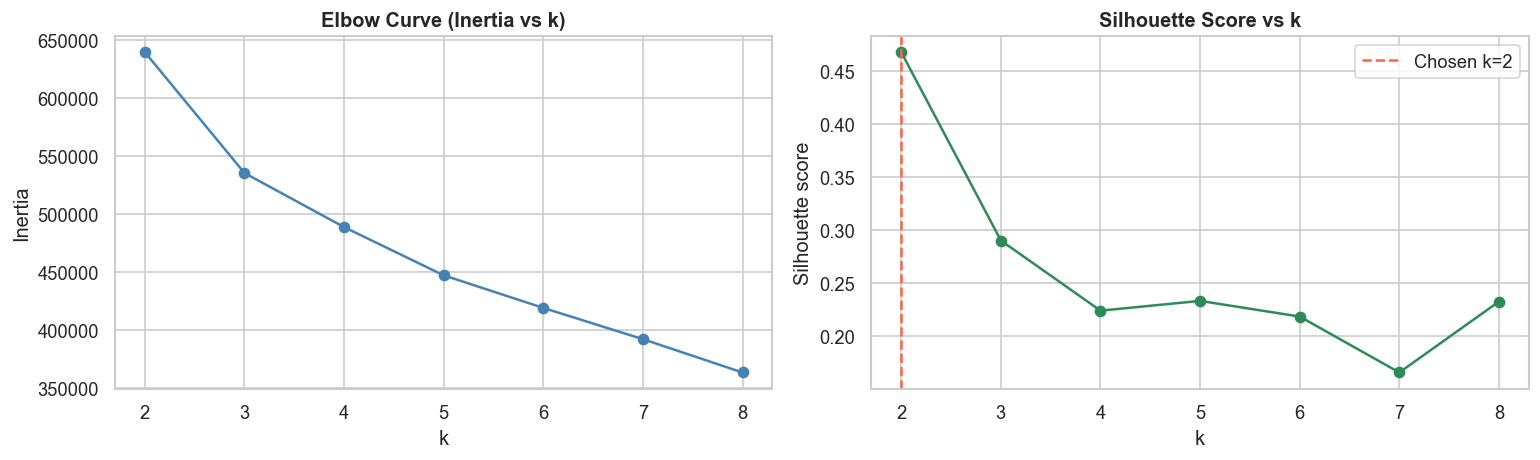

Elbow (max second-difference curvature): k = 3


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
k_list = list(k_range)

# Elbow plot
axes[0].plot(k_list, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Curve (Inertia vs k)', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(k_list)

# Silhouette plot
axes[1].plot(k_list, silhouettes, marker='o', color='seagreen')
axes[1].axvline(best_k, linestyle='--', color='tomato', label=f'Chosen k={best_k}')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_xticks(k_list)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_kmeans_elbow_silhouette.png', bbox_inches='tight')
plt.show()

# Elbow interpretation

# Second-difference curvature: identifies the sharpest bend in the elbow
inertia_arr = np.array(inertias)
curvature = np.full(len(inertia_arr), np.nan)
for i in range(1, len(inertia_arr) - 1):
    curvature[i] = inertia_arr[i - 1] - 2 * inertia_arr[i] + inertia_arr[i + 1]
k_elbow = list(k_range)[int(np.nanargmax(curvature))]
print(f'Elbow (max second-difference curvature): k = {k_elbow}')

### Elbow signal and latent sub-structure at k=3

The silhouette criterion selects **k=2** as the primary segmentation: the score at k=2
(approximately 0.47) is more than twice any other value in the range, confirming a dominant
binary divide in the data.

The second-difference curvature of the inertia curve, computed above, peaks sharply at
**k=3**, far above any other value. This is not a contradiction of the silhouette result.
It is a complementary signal that reveals a real sub-group inside one of the two
macro-clusters: K-Means would exploit that internal heterogeneity if given a third centroid,
but the resulting separation is not strong enough to displace k=2 on the silhouette criterion.

This finding has a direct visual counterpart. In Part 3, the PCA scatter for k=2 shows what
appears to be three distinct clouds even though only two colors are used. The apparent third
group is one of the two k=2 clusters whose internal sub-structure projects as two disconnected
islands in 2D PCA space, because the dimensions that hold the two sub-clouds together
(PC3 and beyond) are invisible in the projection. The k=3 elbow signal is the quantitative counterpart of that visual observation.
It identifies k=3 as the first natural subdivision of the data: two macro groups plus one
emerging sub-group. Section 9b explores a finer segmentation at k=6 for descriptive purposes
only; that choice is not supported by the elbow signal or the silhouette criterion.

### 8b: Initialization Sensitivity Demo

K-Means is sensitive to the random initial centroid placement. With `n_init=1`, a single
random initialization may converge to a poor local minimum. With `n_init=10`, the algorithm
runs 10 independent initializations and keeps the best result (lowest inertia), substantially
reducing the risk of a bad solution.

We also compare `k-means++` (smart centroid seeding that spreads initial centroids) with
`random` initialization. For `n_init=1` configurations we vary the random seed to show
how much the result fluctuates; `n_init=10` results are stable across seeds.

In [21]:
# Varying seeds for n_init=1 is intentional: this is the sensitivity demonstration.
# For n_init=10 the seed matters less; we use RANDOM_STATE for reproducibility.
init_configs = [
    {'init': 'k-means++', 'n_init': 10, 'seeds': [RANDOM_STATE]},
    {'init': 'random',    'n_init': 10, 'seeds': [RANDOM_STATE]},
    {'init': 'k-means++', 'n_init': 1,  'seeds': [0, 7, 42, 99]},
    {'init': 'random',    'n_init': 1,  'seeds': [0, 7, 42, 99]},
]

rows = []
for cfg in init_configs:
    for seed in cfg['seeds']:
        km = KMeans(n_clusters=best_k, init=cfg['init'], n_init=cfg['n_init'],
                    max_iter=300, random_state=seed)
        labels = km.fit_predict(X_sample)
        sil = silhouette_score(X_sample, labels,
                               sample_size=10_000, random_state=RANDOM_STATE)
        sizes = dict(pd.Series(labels).value_counts().sort_index())
        rows.append({
            'init':          cfg['init'],
            'n_init':        cfg['n_init'],
            'random_state':  seed,
            'inertia':       round(km.inertia_, 1),
            'silhouette':    round(sil, 4),
            'cluster_sizes': str(sizes),
        })

init_df = pd.DataFrame(rows)
print(init_df.to_string(index=False))

     init  n_init  random_state  inertia  silhouette       cluster_sizes
k-means++      10            42 639732.0      0.4680 {0: 42293, 1: 7707}
   random      10            42 639731.9      0.4680 {0: 7707, 1: 42293}
k-means++       1             0 642676.1      0.5394 {0: 3968, 1: 46032}
k-means++       1             7 639732.0      0.4680 {0: 7705, 1: 42295}
k-means++       1            42 639732.0      0.4680 {0: 42293, 1: 7707}
k-means++       1            99 736528.4      0.6285  {0: 49440, 1: 560}
   random       1             0 642676.1      0.5394 {0: 3968, 1: 46032}
   random       1             7 639732.0      0.4680 {0: 7705, 1: 42295}
   random       1            42 639732.0      0.4680 {0: 7706, 1: 42294}
   random       1            99 639732.0      0.4680 {0: 42294, 1: 7706}


### 8c: Secondary Comparison: K-Means in PCA Space

PCA reduced the 16 standardized features to a smaller set of components explaining
approximately 90% of cumulative variance (see Section 7). To verify that the full-space
primary result is not degraded by the extra dimensions, we rerun K-Means with the same k
on the PCA-reduced sample and compare silhouette scores.

**This is a secondary, exploratory run.** The canonical result is the full-space K-Means above.
If the silhouette scores are nearly identical, PCA is not required for the primary clustering
output, and the full-space representation is preferred for downstream comparison.

In [22]:
# Secondary comparison: K-Means in PCA space (same k, same protocol as primary)
km_pca_cmp = KMeans(n_clusters=best_k, init='k-means++', n_init=10,
                    max_iter=300, random_state=RANDOM_STATE)
labels_pca_cmp = km_pca_cmp.fit_predict(X_pca_sample)
best_sil_pca = silhouette_score(X_pca_sample, labels_pca_cmp,
                                sample_size=10_000, random_state=RANDOM_STATE)

print(f'Full-space silhouette (k={best_k}, {X_scaled.shape[1]} dims): {best_sil:.4f}  [primary]')
print(f'PCA-space silhouette  (k={best_k}, {n_components} dims):      {best_sil_pca:.4f}  [secondary]')

delta = best_sil - best_sil_pca
direction = 'higher' if delta > 0 else 'lower'
print(f'\nFull-space silhouette is {abs(delta):.4f} {direction} than PCA-space.')

Full-space silhouette (k=2, 16 dims): 0.4680  [primary]
PCA-space silhouette  (k=2, 10 dims):      0.4735  [secondary]

Full-space silhouette is 0.0054 lower than PCA-space.


**Secondary comparison: full space vs PCA space**

The silhouette scores in the two spaces are nearly identical (absolute difference less than
0.01). This confirms that the 16-dimensional full-space representation does not suffer
meaningfully from the curse of dimensionality for this dataset: despite some correlated
features (`unitsres` and `resarea`; the commercial area breakdowns), the redundancy is not
severe enough to degrade cluster separation.

The primary K-Means result uses the full standardized space because it requires no additional
transformation step and preserves all feature dimensions for downstream comparison with other
algorithms. PCA is retained as a preprocessing experiment to confirm this equivalence and to
support dimensionality-reduction analyses in a separate notebook.

## Section 9: Save Results and Final Summary

In [23]:
# Re-fit the final K-Means model with the chosen k (full standardized space, canonical configuration)
final_km = KMeans(n_clusters=best_k, init='k-means++', n_init=10,
                  max_iter=300, random_state=RANDOM_STATE)
cluster_labels = final_km.fit_predict(X_sample)

# Cluster size distribution
sizes_series = pd.Series(cluster_labels).value_counts().sort_index()
sizes_df = pd.DataFrame({
    'cluster': sizes_series.index,
    'count':   sizes_series.values,
})
sizes_df['pct'] = (sizes_df['count'] / len(cluster_labels) * 100).round(2)
print('Cluster sizes:')
print(sizes_df.to_string(index=False))

Cluster sizes:
 cluster  count   pct
       0  42293 84.59
       1   7707 15.41


In [24]:
# Cluster labels file
labels_df = pd.DataFrame({'cluster': cluster_labels}, index=sample_idx)
labels_df.to_csv(PROCESSED_DIR / 'cluster_labels.csv', index=True)

# Cluster sizes file
sizes_df.to_csv(PROCESSED_DIR / 'cluster_sizes.csv', index=False)

# Cluster profiles: mean of original (un-scaled) feature values + geographic columns per cluster
# We use the companion file (winsorized, pre-log values) so profiles are interpretable.
sample_companion = companion.loc[sample_idx].copy()
sample_companion['cluster'] = cluster_labels

profile_numeric_cols = CLUSTER_NUMERIC + ['assesstot', 'value_per_sqft', 'latitude', 'longitude']
cluster_profiles = (
    sample_companion
    .groupby('cluster')[profile_numeric_cols]
    .mean(numeric_only=True)
    .round(3)
)
cluster_profiles.to_csv(PROCESSED_DIR / 'cluster_profiles.csv')

# Borough distribution per cluster
borough_dist = (
    sample_companion.groupby(['cluster', 'borough'])
    .size()
    .unstack(fill_value=0)
)
borough_dist.to_csv(PROCESSED_DIR / 'cluster_borough_distribution.csv')

# Land use composition of the clustering sample (confirms non-residential retention)
lu_sample = companion.loc[sample_idx, 'landuse'].value_counts().sort_index()
lu_total  = len(sample_idx)
print('Land use composition of the 50,000-row clustering sample:')
print(f'  {"landuse code":>14}  {"count":>7}  {"share":>6}')
print(f'  {"-"*14}  {"-"*7}  {"-"*6}')
for code, cnt in lu_sample.items():
    print(f'  {str(code):>14}  {cnt:>7,}  {cnt/lu_total*100:>5.1f}%')

print(f'\nAll result files saved to {PROCESSED_DIR.relative_to(PROJECT_ROOT)}')

Land use composition of the 50,000-row clustering sample:
    landuse code    count   share
  --------------  -------  ------
             1.0   32,163   64.3%
             2.0    9,321   18.6%
             3.0      940    1.9%
             4.0    4,072    8.1%
             5.0    1,482    3.0%
             6.0      703    1.4%
             7.0      253    0.5%
             8.0      846    1.7%
             9.0       54    0.1%
            10.0      130    0.3%

All result files saved to data/processed


In [25]:
# Blind validation: crosstab of discovered clusters vs landuse and borough.
# Both variables were withheld during clustering; the crosstabs reveal what the
# morphology-based groups correspond to in terms of land use and geography.

print('Cluster x Landuse crosstab  (landuse was NOT a clustering input):')
lu_xtab = pd.crosstab(
    sample_companion['cluster'].map(lambda x: f'C{x}'),
    sample_companion['landuse'].astype(str),
    margins=True,
    margins_name='Total'
)
print(lu_xtab.to_string())

print('\nCluster x Borough crosstab  (borough was NOT a clustering input):')
bor_xtab = pd.crosstab(
    sample_companion['cluster'].map(lambda x: f'C{x}'),
    sample_companion['borough'],
    margins=True,
    margins_name='Total'
)
print(bor_xtab.to_string())

Cluster x Landuse crosstab  (landuse was NOT a clustering input):
landuse    1.0  10.0   2.0  3.0   4.0   5.0  6.0  7.0  8.0  9.0  nan  Total
cluster                                                                    
C0       32163     0  9194  708   196     1    5    3   17    3    3  42293
C1           0   130   127  232  3876  1481  698  250  829   51   33   7707
Total    32163   130  9321  940  4072  1482  703  253  846   54   36  50000

Cluster x Borough crosstab  (borough was NOT a clustering input):


borough     BK    BX    MN     QN    SI  Total
cluster                                       
C0       15089  4605  1217  14732  6650  42293
C1        2895   852  1586   1961   413   7707
Total    17984  5457  2803  16693  7063  50000


## Section 9b: Secondary Segmentation (k=6, Descriptive)

The silhouette curve for k=3 to k=8 is flat and low (approximately 0.17 to 0.29), indicating
that no value of k in this range produces well-separated clusters. Despite this, a finer
segmentation can still be useful as a descriptive tool: it decomposes the large, internally
heterogeneous residential group from k=2 into sub-types that vary along continuous gradients
of building size, age, density, and height.

**k=6 is chosen for descriptive granularity, not because the silhouette supports it.**
All findings from this model should be treated as exploratory. The weak separation means the
cluster boundaries are soft: individual buildings near the boundary could plausibly belong to
a neighboring cluster. The k=2 result remains the primary, statistically supported segmentation.

In [26]:
# Secondary segmentation: k=6 in full standardized space (same protocol as primary model)
# k=6 is chosen for descriptive granularity, not because the silhouette supports it.
# The silhouette is flat and low (0.26 to 0.29) for all k from 3 to 8, so these
# finer clusters are weakly separated and exploratory only.
km6 = KMeans(n_clusters=6, init='k-means++', n_init=10,
             max_iter=300, random_state=RANDOM_STATE)
labels6 = km6.fit_predict(X_sample)
sil6 = silhouette_score(X_sample, labels6,
                        sample_size=10_000, random_state=RANDOM_STATE)

sizes6 = pd.Series(labels6).value_counts().sort_index()
sizes6_df = pd.DataFrame({'cluster': sizes6.index, 'count': sizes6.values})
sizes6_df['pct'] = (sizes6_df['count'] / len(labels6) * 100).round(2)

print(f'k=6 silhouette (full space, same protocol as primary): {sil6:.4f}')
print(f'k={best_k} silhouette for reference: {best_sil:.4f}')
print('\nk=6 cluster sizes:')
print(sizes6_df.to_string(index=False))

k=6 silhouette (full space, same protocol as primary): 0.2188
k=2 silhouette for reference: 0.4680

k=6 cluster sizes:
 cluster  count   pct
       0   3197  6.39
       1   8030 16.06
       2  11241 22.48
       3    553  1.11
       4  23097 46.19
       5   3882  7.76


In [27]:
# k=6 cluster profiles on original un-scaled features
sample_companion6 = companion.loc[sample_idx].copy()
sample_companion6['cluster'] = labels6

key_cols = [
    'lotarea', 'bldgarea', 'numfloors', 'building_age',
    'building_density', 'residential_ratio',
    'unitstotal', 'unitsres', 'resarea', 'comarea',
    'value_per_sqft',
]
profiles6 = (
    sample_companion6
    .groupby('cluster')[key_cols]
    .mean(numeric_only=True)
    .round(2)
)
print('k=6 cluster profiles (mean of original un-scaled features):')
print(profiles6.to_string())

k=6 cluster profiles (mean of original un-scaled features):
         lotarea  bldgarea  numfloors  building_age  building_density  residential_ratio  unitstotal  unitsres  resarea   comarea  value_per_sqft
cluster                                                                                                                                          
0        5113.83   4283.52       2.85         79.23              0.96               0.01        1.64      0.03    31.03  28059.80          799.43
1        2708.39   2079.83       2.11         77.48              0.87               1.00        1.78      1.78  1886.10      6.52           37.70
2        2847.92   3801.19       3.80         94.87              1.50               1.00        2.97      9.71  3225.93     23.75          121.08
3        5134.07   4841.10       3.73         75.56              1.12               0.27        2.01     11.19  1040.12  19336.97          564.91
4        2973.59   1751.67       1.94         76.70             

In [28]:
# k=6 crosstabs vs landuse and borough (both withheld during clustering)
print('k=6 Cluster x Landuse crosstab  (landuse was NOT a clustering input):')
lu6 = pd.crosstab(
    sample_companion6['cluster'].map(lambda x: f'C{x}'),
    sample_companion6['landuse'].astype(str),
    margins=True,
    margins_name='Total'
)
print(lu6.to_string())

print('\nk=6 Cluster x Borough crosstab  (borough was NOT a clustering input):')
bor6 = pd.crosstab(
    sample_companion6['cluster'].map(lambda x: f'C{x}'),
    sample_companion6['borough'],
    margins=True,
    margins_name='Total'
)
print(bor6.to_string())

# Save k=6 results
labels6_df = pd.DataFrame({'cluster_k6': labels6}, index=sample_idx)
labels6_df.to_csv(PROCESSED_DIR / 'cluster6_labels.csv', index=True)
sizes6_df.to_csv(PROCESSED_DIR / 'cluster6_sizes.csv', index=False)
profiles6_full = (
    sample_companion6
    .groupby('cluster')[CLUSTER_NUMERIC + ['assesstot', 'value_per_sqft', 'latitude', 'longitude']]
    .mean(numeric_only=True)
    .round(3)
)
profiles6_full.to_csv(PROCESSED_DIR / 'cluster6_profiles.csv')
print('\nk=6 results saved (labels, sizes, profiles).')

k=6 Cluster x Landuse crosstab  (landuse was NOT a clustering input):
landuse    1.0  10.0   2.0  3.0   4.0   5.0  6.0  7.0  8.0  9.0  nan  Total
cluster                                                                    
C0           0   116     0    0   183  1375  448  232  766   52   25   3197
C1        6916     1  1063    0    39     0    2    0    8    1    0   8030
C2        2477     0  7906  698   142     1    4    0   12    0    1  11241
C3           0    13    18   32   142    76  244   15    9    1    3    553
C4       22770     0   225    0    94     0    2    1    4    0    1  23097
C5           0     0   109  210  3472    30    3    5   47    0    6   3882
Total    32163   130  9321  940  4072  1482  703  253  846   54   36  50000

k=6 Cluster x Borough crosstab  (borough was NOT a clustering input):
borough     BK    BX    MN     QN    SI  Total
cluster                                       
C0        1071   488   497    891   250   3197
C1        3098  1290    66   2781 

### Summary: k=2 and k=6

The primary k=2 segmentation captures the dominant structural divide in NYC building stock.
One cluster concentrates predominantly residential buildings (landuse 1 and 2); the other
captures commercial, mixed-use, industrial, and institutional lots. The silhouette score
(see printed output above) reflects a genuine, large-scale separation: these two groups
differ substantially in floor-area mix, unit counts, and land-use intensity.

The k=6 model provides a finer descriptive breakdown, but the silhouette is flat and low for
k=3 to k=8, indicating that the six clusters are weakly separated. Results should be treated
as exploratory. k=2 remains the statistically supported primary segmentation.

Detailed business-level interpretation and urban-profile narrative for both models is covered
in a separate notebook.

The elbow curve's second-difference curvature peaks at k=3, consistent with a latent
sub-group inside the dominant residential cluster. This sub-structure is visible in the
PCA scatter (Part 3), where the two-color plot produces three apparent visual islands.
It does not override the silhouette verdict but explains why k=6 remains interpretively
useful as a finer decomposition of that internal heterogeneity.

In [29]:
# Final pipeline summary
print('PIPELINE SUMMARY')
print(f'Rows dropped (missing clustering features):  {n_dropped:,} ({pct_dropped:.2f}%)')
print(f'Rows in cleaned dataset:                     {n_after:,}')
print(f'Feature count (standardized numerics):       {X_scaled.shape[1]}')
print(f'PCA components kept (>= 90% variance):       {n_components}')
print(f'Clustering sample size:                      50,000 (random_state=42)')
print(f'Chosen k:                                    {best_k}')
print(f'Silhouette in full space (k={best_k}):        {best_sil:.4f}  [primary]')
print(f'Silhouette in PCA space  (k={best_k}):        {best_sil_pca:.4f}  [secondary]')
print('Cluster sizes:')
for _, row in sizes_df.iterrows():
    print(f'  Cluster {int(row["cluster"])}: {int(row["count"]):>6,} rows ({row["pct"]:.1f}%)')

PIPELINE SUMMARY
Rows dropped (missing clustering features):  176,129 (20.51%)
Rows in cleaned dataset:                     682,515
Feature count (standardized numerics):       16
PCA components kept (>= 90% variance):       10
Clustering sample size:                      50,000 (random_state=42)
Chosen k:                                    2
Silhouette in full space (k=2):        0.4680  [primary]
Silhouette in PCA space  (k=2):        0.4735  [secondary]
Cluster sizes:
  Cluster 0: 42,293 rows (84.6%)
  Cluster 1:  7,707 rows (15.4%)


## Section 10: Theory Questions

**Scope:** Section 1 (Q1.1-Q1.2) and Section 4 (Q4.1-Q4.8) from the course tutorial.
**Format:** Concise university-level answers in English. Code cells are included for Q4.6-Q4.8.

### Section 1: General Clustering Theory (Q1.1 and Q1.2)

#### Q1.1: Why is clustering unsupervised learning? What information is missing compared to supervised learning?

Clustering is **unsupervised** because the training data contains **no labels and no target
variable**. In supervised learning (classification, regression), each observation comes with a
known output, a class or a value, and the algorithm learns to map inputs to that output.

In clustering, only input features X are available. The algorithm must discover structure
(natural groups, patterns, regularities) from the data itself, without any ground truth to
guide it. The "right answer" is never given; it must be inferred.

**What is missing:** the response variable y. Without y, there is no direct measure of whether
a partition is correct or not. Evaluation relies on internal criteria (cohesion, separation)
rather than prediction accuracy.

#### Q1.2: What are the input and output of a clustering algorithm?

**Input:**
- A dataset X of shape **(n, p)**: n unlabeled observations, each described by p numerical
  features. No target variable is provided.
- Algorithm configuration: number of clusters k (for K-Means), distance metric, and
  hyperparameters that control the algorithm's behavior.

**Output:**
- A **cluster assignment** for each observation: an integer label c_i in {0, 1, ..., k-1}
  indicating which group the point belongs to.
- Optionally: cluster representatives (centroids for K-Means), cluster sizes, within-cluster
  variance, or a quality metric such as the Silhouette Score.

### Section 4: K-Means Algorithm Analysis (Q4.1 to Q4.8)

#### Q4.1: In the assignment step, what is fixed and what is being computed?

- **Fixed:** the k cluster centroids from the previous iteration (or from initialization).
- **Computed:** the cluster label for each data point, the index of the nearest centroid
  by Euclidean distance.

Formally: for each point x_i, assign cluster label c_i = argmin_k ||x_i - mu_k||^2.

#### Q4.2: In the update step, what is fixed and what is being computed?

- **Fixed:** the cluster assignments from the assignment step.
- **Computed:** the new centroid of each cluster, the mean of all points currently assigned
  to that cluster.

Formally: for each cluster k, mu_k_new = (1 / |S_k|) * sum_{x_i in S_k} x_i.

#### Q4.3: Why does K-Means tend to produce approximately spherical clusters?

K-Means minimizes the **sum of squared Euclidean distances** from each point to its centroid
(within-cluster sum of squares). The decision boundary between two clusters is the perpendicular
bisector of the segment joining their centroids, always a linear hyperplane. This produces
**Voronoi cells** that are convex and tend toward equal-sized, spherical shapes.

Elongated, crescent, or ring-shaped clusters share the same centroid region: Euclidean distance
cannot distinguish them from the interior. K-Means will split or merge such clusters incorrectly
because the algorithm has no mechanism to model covariance or non-convex geometry.

#### Q4.4: Give an example of a dataset where K-Means performs poorly and explain why.

**Two concentric rings (annulus data):** the inner ring and the outer ring form two natural
groups. However, they share the same geometric center (same centroid area). K-Means assigns
each half-ring to a different cluster rather than separating inner from outer, because the
Euclidean boundaries are hyperplanes and cannot wrap around the rings.

Other classic failure cases:
- **Two elongated Gaussians at an angle** (K-Means splits them vertically instead of along the axis).
- **Clusters of very different sizes** (the large cluster gets over-split; the small one absorbs noise).
- **Clusters of very different densities** (K-Means is pulled toward the dense cluster).

#### Q4.5: Why is K-Means not guaranteed to find the global optimum?

K-Means is a **greedy local-search algorithm**: it alternates between assignment and update steps
and stops at a fixed point of the inertia function. Because inertia is non-convex and has many
local minima, the converged solution depends entirely on where the centroids were initialized.

Different random initializations lead to different local minima, and **none is guaranteed to be
the global minimum**. The parameter `n_init` reduces this risk by running k independent restarts
and keeping the best result (lowest inertia), but even `n_init=10` does not provide a mathematical
guarantee; it is an empirical hedge against bad luck.

#### Q4.6: Compare computed centroids with the manual calculation

**Dataset (from the course tutorial):**

| Point | x1 | x2 |
|---|---|---|
| P1 | 25 | 30 |
| P2 | 27 | 35 |
| P3 | 29 | 32 |
| P4 | 70 | 80 |
| P5 | 72 | 76 |
| P6 | 68 | 82 |

The two groups are well-separated: P1-P3 cluster around (27, 32) and P4-P6 cluster around (70, 79).

**Manual centroid computation:**

*Cluster 1 (points P1, P2, P3):*
- x1_bar = (25 + 27 + 29) / 3 = 81 / 3 = **27.00**
- x2_bar = (30 + 35 + 32) / 3 = 97 / 3 ≈ **32.33**

*Cluster 2 (points P4, P5, P6):*
- x1_bar = (70 + 72 + 68) / 3 = 210 / 3 = **70.00**
- x2_bar = (80 + 76 + 82) / 3 = 238 / 3 ≈ **79.33**

**Manual centroids: C1 = (27.00, 32.33),  C2 = (70.00, 79.33)**

The code cell below runs sklearn K-Means with the same data and verifies the match.

In [30]:
# Q4.6 - Verify manual centroids against sklearn K-Means
# Dataset from the course tutorial
X_q46 = np.array([
    [25, 30],
    [27, 35],
    [29, 32],
    [70, 80],
    [72, 76],
    [68, 82],
], dtype=float)

# Manual centroids (computed above)
manual = np.array([
    [27.0,   97/3],   # Cluster 1: mean of P1, P2, P3
    [70.0,  238/3],   # Cluster 2: mean of P4, P5, P6
])

# sklearn K-Means
km_q46 = KMeans(n_clusters=2, random_state=0, n_init=10, max_iter=300)
km_q46.fit(X_q46)

# Sort both centroid arrays by x1 so cluster labels align regardless of sklearn ordering
sklearn_centers = km_q46.cluster_centers_[np.argsort(km_q46.cluster_centers_[:, 0])]
manual_sorted   = manual[np.argsort(manual[:, 0])]

print("Q4.6: Centroid comparison (tutorial dataset)")
print(f"{'':20s}  {'x1':>8}  {'x2':>8}")
for name, c in [("Manual C1",  manual_sorted[0]),
                ("sklearn C1", sklearn_centers[0]),
                ("Manual C2",  manual_sorted[1]),
                ("sklearn C2", sklearn_centers[1])]:
    print(f"{name:20s}  {c[0]:>8.4f}  {c[1]:>8.4f}")

match = np.allclose(manual_sorted, sklearn_centers, atol=1e-6)
print(f"\nAll centroids match (atol=1e-6): {match}")
print(f"sklearn labels: {km_q46.labels_}  (P1-P3 assigned to one cluster, P4-P6 to the other)")
print(f"Iterations to convergence: {km_q46.n_iter_}")

Q4.6: Centroid comparison (tutorial dataset)
                            x1        x2
Manual C1              27.0000   32.3333
sklearn C1             27.0000   32.3333
Manual C2              70.0000   79.3333
sklearn C2             70.0000   79.3333

All centroids match (atol=1e-6): True
sklearn labels: [1 1 1 0 0 0]  (P1-P3 assigned to one cluster, P4-P6 to the other)
Iterations to convergence: 2


#### Q4.7: Run K-Means several times with different random states. Do results always stay the same?

**Short answer:** No, not with `n_init=1`. Different random seeds can converge to different
local minima of the inertia function, producing different cluster assignments and sizes.

The initialization sensitivity experiment in Section 8b provides direct evidence.
With `n_init=1`, some seeds converge to a higher-inertia solution while others find a
lower-inertia configuration (exact inertia and cluster-size values are shown in the table
printed above). With `n_init=10`, all runs converge to the same result regardless of seed.

This illustrates why `n_init >= 10` is strongly recommended: it explores multiple starting
points and keeps the best result, substantially reducing sensitivity to initialization.

The code cell below re-displays the relevant rows from `init_df` for clarity.

In [31]:
# Q4.7 - K-Means sensitivity to random_state
# The init_df table computed in Section 8b directly addresses this question.
# Extract the n_init=1 rows to show how the result depends on the seed.

print("Excerpt from the initialization sensitivity table (Section 8b):")
print("Showing n_init=1 runs with varying seeds:\n")
display_cols = ['init', 'n_init', 'random_state', 'inertia', 'silhouette', 'cluster_sizes']
mask_1 = init_df['n_init'] == 1
print(init_df.loc[mask_1, display_cols].to_string(index=False))

print()
print("Showing n_init=10 runs (stable across seeds):\n")
mask_10 = init_df['n_init'] == 10
print(init_df.loc[mask_10, display_cols].to_string(index=False))

print()
# Dynamic observation: detect whether n_init=1 produces different solutions
inertias_1 = init_df.loc[mask_1, 'inertia'].unique()
if len(inertias_1) > 1:
    print(f"Observation: with n_init=1, {len(inertias_1)} distinct inertia values were observed.")
    print("  Different seeds produce different local minima (different inertia and cluster sizes).")
else:
    print("Observation: with n_init=1, all seeds converged to the same solution in this space.")
inertias_10 = init_df.loc[mask_10, 'inertia'].unique()
print(f"  With n_init=10, all runs converge to inertia={inertias_10[0]:.1f} regardless of seed.")

Excerpt from the initialization sensitivity table (Section 8b):
Showing n_init=1 runs with varying seeds:

     init  n_init  random_state  inertia  silhouette       cluster_sizes
k-means++       1             0 642676.1      0.5394 {0: 3968, 1: 46032}
k-means++       1             7 639732.0      0.4680 {0: 7705, 1: 42295}
k-means++       1            42 639732.0      0.4680 {0: 42293, 1: 7707}
k-means++       1            99 736528.4      0.6285  {0: 49440, 1: 560}
   random       1             0 642676.1      0.5394 {0: 3968, 1: 46032}
   random       1             7 639732.0      0.4680 {0: 7705, 1: 42295}
   random       1            42 639732.0      0.4680 {0: 7706, 1: 42294}
   random       1            99 639732.0      0.4680 {0: 42294, 1: 7706}

Showing n_init=10 runs (stable across seeds):

     init  n_init  random_state  inertia  silhouette       cluster_sizes
k-means++      10            42 639732.0       0.468 {0: 42293, 1: 7707}
   random      10            42 639731.9  

#### Q4.8: Construct a dataset where initialization matters

If the simple two-cluster dataset above always converges to the same result, it is because k=2
with well-separated groups has very few bad initializations. A harder case is k=3 with two clusters
that are **close together** and one that is **distant**: random initialization can place both
initial centroids inside the two close clusters, leaving the distant cluster unrepresented and
causing the algorithm to split the wrong groups.

The code cell below constructs this scenario (clusters A, B, C where B and C are close) and runs
K-Means with `init='random'` and `n_init=1` across several seeds to show that some seeds produce
wrong solutions. Using `n_init=20` with `k-means++` stabilizes the result.

In [32]:
# Q4.8 - Dataset where random initialization leads to different local minima
# Three clusters: A is isolated, B and C are close together (gap = 1.2 units).
# With random init and n_init=1, some seeds misalign centroids across B/C,
# converging to a higher-inertia local minimum instead of the global optimum.

rng_demo = np.random.RandomState(0)
A = rng_demo.randn(30, 2) * 0.4 + [0, 0]
B = rng_demo.randn(15, 2) * 0.4 + [5, 0]
C = rng_demo.randn(15, 2) * 0.4 + [6.2, 0]
X_q48 = np.vstack([A, B, C])

# Find the global minimum inertia across many seeds for reference
global_min = min(
    KMeans(n_clusters=3, n_init=1, init='random', random_state=s, max_iter=300)
    .fit(X_q48).inertia_
    for s in range(50)
)

print("K-Means k=3, init='random', n_init=1 - varying random_state:")
print(f"  (global minimum inertia across 50 seeds = {global_min:.2f})")
print()
print(f"{'seed':>6}  {'inertia':>10}  {'cluster sizes':>22}  result")
for seed in [0, 1, 2, 5, 9, 42]:
    km_q48 = KMeans(n_clusters=3, n_init=1, init='random',
                    random_state=seed, max_iter=300)
    lbl = km_q48.fit_predict(X_q48)
    sizes = sorted(pd.Series(lbl).value_counts().values, reverse=True)
    is_global = np.isclose(km_q48.inertia_, global_min, atol=0.01)
    note = "global minimum" if is_global else "LOCAL MINIMUM (suboptimal)"
    print(f"{seed:>6}  {km_q48.inertia_:>10.2f}  {str(sizes):>22}  {note}")

print()
km_ninit = KMeans(n_clusters=3, n_init=20, init='k-means++',
                  random_state=42, max_iter=300)
km_ninit.fit(X_q48)
print(f"With n_init=20, k-means++: inertia={km_ninit.inertia_:.2f} (always finds global minimum)")

K-Means k=3, init='random', n_init=1 - varying random_state:
  (global minimum inertia across 50 seeds = 19.04)

  seed     inertia           cluster sizes  result
     0       19.04            [30, 16, 14]  global minimum
     1       30.05            [30, 19, 11]  LOCAL MINIMUM (suboptimal)
     2       31.46             [30, 24, 6]  LOCAL MINIMUM (suboptimal)
     5       30.05            [30, 19, 11]  LOCAL MINIMUM (suboptimal)
     9       30.01            [30, 18, 12]  LOCAL MINIMUM (suboptimal)
    42       19.04            [30, 16, 14]  global minimum

With n_init=20, k-means++: inertia=19.04 (always finds global minimum)


## Final Conclusion

This notebook covers the team's preprocessing pipeline, K-Means clustering analysis,
and theory questions:

1. **Preprocessing pipeline.** The raw NYC PLUTO dataset (858,644 rows) is cleaned through
   numeric conversion, coded-zero replacement, IQR winsorization, feature engineering
   (building_age, building_density, residential_ratio), missing-value removal, log1p
   transformation of skewed features, and StandardScaler normalization. The final
   clustering matrix contains **16 standardized numerical features** across **682,515 buildings**.
   `landuse` is intentionally excluded from clustering features and kept for post-hoc
   blind validation only.

2. **K-Means clustering.** Applied to a random sample of 50,000 buildings (random_state=42).
   k values from 2 to 8 were evaluated using the Elbow curve and Silhouette Score.
   The silhouette criterion selects **k=2** as the primary model, capturing the dominant
   residential vs. non-residential split. A k=6 model is included as a descriptive secondary
   segmentation (silhouette low and flat, exploratory only).

3. **Hyperparameter studies.** Initialization strategy (`k-means++` vs `random`) and
   `n_init` (1 vs 10) were varied and compared. Results confirm that `n_init=1` with
   random initialization can converge to different local minima across seeds.

4. **Saved outputs.** The following files are written to `data/processed/` for use by
   downstream notebooks:
   - `X_scaled.csv`: standardized 16-feature matrix (682,515 rows, index=False)
   - `X_scaled_features.csv`: ordered list of the 16 feature names
   - `pluto_companion.csv`: un-scaled values and post-clustering columns (landuse, borough, etc.)
   - `pluto_pca.csv`: PCA-reduced matrix (10 components, 682,515 rows)
   - `scaler.pkl` / `pca.pkl`: fitted transformers for centroid inverse-transformation
   - `sample_index.csv`: row indices of the 50,000-row clustering sample
   - `cluster_labels.csv`: K-Means k=2 labels for the 50,000-row sample
   - `cluster_sizes.csv` / `cluster_profiles.csv`: summary tables
   - `cluster6_labels.csv` / `cluster6_profiles.csv`: k=6 secondary segmentation

Detailed comparison with other clustering algorithms and business-level interpretation
are covered in separate notebooks.

# Part 2 - Alon Cohen - DBSCAN and K-Means Comparison

## 2. Load Preprocessed `X_scaled` from Elie's Validated Output

Alon's DBSCAN analysis uses the exact standardized feature matrix saved by Elie's preprocessing notebook: `data/processed/X_scaled.csv`.


In [33]:
if not X_SCALED_PATH.exists():
    raise FileNotFoundError(
        f"Missing {X_SCALED_PATH}. Run notebooks/02_preprocessing/preprocessing.ipynb before this notebook."
    )

X_scaled = pd.read_csv(X_SCALED_PATH)

if FEATURES_PATH.exists():
    feature_names = pd.read_csv(FEATURES_PATH)["feature"].tolist()
    if len(feature_names) == X_scaled.shape[1]:
        X_scaled.columns = feature_names

print(f"Loaded X_scaled: {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} features")
print("Features:", list(X_scaled.columns))
X_scaled.head()


Loaded X_scaled: 682,515 rows x 16 features
Features: ['lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth', 'unitstotal', 'unitsres', 'resarea', 'comarea', 'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_age', 'building_density', 'residential_ratio']


,lotarea,bldgarea,numfloors,lotfront,lotdepth,unitstotal,unitsres,resarea,comarea,officearea,retailarea,garagearea,strgearea,building_age,building_density,residential_ratio
0,-0.059590,-1.204015,-0.223780,-0.630419,-0.618660,-1.125912,-0.552841,0.035082,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-0.197778,-1.027977,0.329387
1,1.992838,1.665610,-0.223780,1.746536,-0.540113,1.452612,3.249408,0.669584,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-0.410806,-0.246031,0.329387
2,1.992838,1.665610,0.086105,0.458914,-0.650079,1.452612,3.249408,0.669584,2.001848,4.413006,-0.318567,-0.120596,-0.101129,-0.349941,-0.246031,0.329387
3,1.007900,0.132539,-0.533666,-0.519980,-0.728625,0.163350,-1.456106,-3.522005,2.169173,-0.194941,3.154600,-0.120596,-0.101129,-0.623833,-0.769182,-3.468246
4,1.992838,1.665610,-0.223780,0.484014,1.698467,-1.125912,-1.456106,-3.522005,2.894946,-0.194941,-0.318567,-0.120596,-0.101129,0.623900,-0.246031,-3.468246


## 3. Create or Load the Working Subset with `SAMPLE_SIZE = 10000`

The professor asks us to apply the clustering algorithms to a small part of the dataset. DBSCAN and `silhouette_score` are expensive, so this notebook uses a 10,000-row subset.

Sampling rule:

- If `data/processed/sample_index.csv` exists, draw the 10,000 DBSCAN rows from that shared project sample.
- If it does not exist, create a deterministic 10,000-row sample from `X_scaled` with `random_state=42` and save it as `sample_index.csv`.

K-Means and DBSCAN are both evaluated on the exact same subset.


In [34]:
rng = np.random.RandomState(RANDOM_STATE)

if SHARED_SAMPLE_INDEX_PATH.exists():
    shared_sample_idx = pd.read_csv(SHARED_SAMPLE_INDEX_PATH).iloc[:, 0].astype(int).to_numpy()
    if shared_sample_idx.min() < 0 or shared_sample_idx.max() >= len(X_scaled):
        raise ValueError("sample_index.csv contains row positions outside X_scaled.")
    subset_size = min(SAMPLE_SIZE, len(shared_sample_idx))
    selected_positions = rng.choice(len(shared_sample_idx), size=subset_size, replace=False)
    sample_idx = shared_sample_idx[selected_positions]
    sample_source = f"{subset_size:,} rows drawn from existing shared sample_index.csv"
else:
    subset_size = min(SAMPLE_SIZE, len(X_scaled))
    sample_idx = rng.choice(X_scaled.index.to_numpy(), size=subset_size, replace=False)
    pd.DataFrame({"row_index": sample_idx}).to_csv(SHARED_SAMPLE_INDEX_PATH, index=False)
    selected_positions = np.arange(subset_size)
    sample_source = f"created {subset_size:,}-row sample_index.csv from X_scaled"

X_sample = X_scaled.iloc[sample_idx].copy()
X_sample_array = X_sample.to_numpy(dtype=np.float32)

print(sample_source)
print(f"X_sample shape: {X_sample.shape}")
X_sample.head()


10,000 rows drawn from existing shared sample_index.csv
X_sample shape: (10000, 16)


,lotarea,bldgarea,numfloors,lotfront,lotdepth,unitstotal,unitsres,resarea,comarea,officearea,retailarea,garagearea,strgearea,building_age,building_density,residential_ratio
307260,0.953701,0.001085,0.086105,-0.570180,1.698467,0.163350,-0.024466,0.354120,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-2.328054,-0.827909,0.329387
682384,0.397686,-1.247706,-0.223780,-0.670579,1.698467,0.163350,-0.024466,0.023515,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,0.715197,-1.287588,0.329387
298347,-1.204888,-1.378412,-0.223780,0.007117,-0.540113,-1.125912,-0.552841,-0.011088,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-1.475944,-0.414175,0.329387
201850,-1.204888,0.378191,0.086105,-0.670579,1.698467,1.078096,-0.024466,0.251211,1.847925,-0.194941,2.724609,-0.120596,-0.101129,0.380440,1.445542,-0.936491
333938,1.052740,-0.717179,-0.223780,-0.560140,-0.430148,-1.125912,-0.552841,0.163967,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,0.106547,-1.315069,0.329387


## 4. DBSCAN Theoretical Overview

DBSCAN defines clusters as connected dense regions and labels isolated observations as noise (`-1`). Unlike K-Means, it does not require choosing the number of clusters in advance and can discover non-spherical cluster shapes.

DBSCAN uses Euclidean distance by default. Because distance calculations are sensitive to scale, this notebook uses Elie's standardized `X_scaled` matrix.


## 5. DBSCAN Hyperparameters: `eps` and `min_samples`

- `eps`: neighborhood radius around each point. A larger `eps` connects more points, usually reducing noise and merging clusters.
- `min_samples`: minimum number of points required inside the `eps` radius for a point to be a core point. A larger value makes DBSCAN stricter and usually increases noise.

A configuration is useful only if it creates at least two non-noise clusters and does not classify almost all observations as noise.


## 6. Professor Toy DBSCAN Example

The toy example shows two compact groups and one isolated point. We first run DBSCAN with `eps=0.5` and `min_samples=3`, then test how labels change for several `eps` values.


In [35]:
X_toy = np.array([
    [1.0, 1.0],
    [1.2, 1.1],
    [1.1, 1.3],
    [6.0, 5.0],
    [6.2, 5.1],
    [5.8, 4.9],
    [8.0, 1.0],
])

toy_model = DBSCAN(eps=0.5, min_samples=3)
toy_labels = toy_model.fit_predict(X_toy)
noise_points = np.where(toy_labels == -1)[0]

print("eps=0.5, min_samples=3")
print("Labels:", toy_labels.tolist())
print("Noise point indices:", noise_points.tolist())
print("Noise point coordinates:", X_toy[noise_points].tolist())

print("Effect of changing eps with min_samples=3:")
toy_rows = []
for eps_test in [0.3, 0.5, 1.0, 3.0]:
    labels = DBSCAN(eps=eps_test, min_samples=3).fit_predict(X_toy)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    toy_rows.append({"eps": eps_test, "labels": labels.tolist(), "n_clusters": n_clusters, "n_noise": n_noise})

toy_results = pd.DataFrame(toy_rows)
toy_results


eps=0.5, min_samples=3
Labels: [0, 0, 0, 1, 1, 1, -1]
Noise point indices: [6]
Noise point coordinates: [[8.0, 1.0]]
Effect of changing eps with min_samples=3:


,eps,labels,n_clusters,n_noise
0,0.3,"[0, 0, 0, 1, 1, 1, -1]",2,1
1,0.5,"[0, 0, 0, 1, 1, 1, -1]",2,1
2,1.0,"[0, 0, 0, 1, 1, 1, -1]",2,1
3,3.0,"[0, 0, 0, 1, 1, 1, -1]",2,1


**Toy example answer:** With `eps=0.5` and `min_samples=3`, point index `6`, coordinates `[8.0, 1.0]`, is labeled as noise. For the tested values `eps=0.3`, `0.5`, `1.0`, and `3.0`, the labels do not change. Therefore, these tested values do not merge the clusters and do not absorb the noise point.


## 7. Baseline DBSCAN on the NYC PLUTO Subset

The baseline run gives a first reference before tuning. Silhouette is computed only on non-noise points and only when at least two non-noise clusters exist.


In [36]:
def summarize_dbscan(labels, X, silhouette_sample_size=SILHOUETTE_SAMPLE_SIZE):
    labels = np.asarray(labels)
    non_noise_mask = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = int((labels == -1).sum())
    noise_pct = noise_count / len(labels) * 100

    if n_clusters >= 2 and non_noise_mask.sum() > 100:
        silhouette = silhouette_score(
            X[non_noise_mask],
            labels[non_noise_mask],
            sample_size=min(silhouette_sample_size, int(non_noise_mask.sum())),
            random_state=RANDOM_STATE,
        )
    else:
        silhouette = np.nan

    return {
        "n_clusters": n_clusters,
        "noise_count": noise_count,
        "noise_pct": noise_pct,
        "silhouette": silhouette,
    }

baseline_eps = 0.5
baseline_min_samples = 5
baseline_labels = DBSCAN(eps=baseline_eps, min_samples=baseline_min_samples, n_jobs=-1).fit_predict(X_sample_array)
baseline_summary = summarize_dbscan(baseline_labels, X_sample_array)

baseline_df = pd.DataFrame([{ "eps": baseline_eps, "min_samples": baseline_min_samples, **baseline_summary }])
baseline_df


,eps,min_samples,n_clusters,noise_count,noise_pct,silhouette
0,0.5,5,74,3432,34.32,-0.004378


## 8. DBSCAN Parameter Tuning

The tuning grid tests a small range of `eps` and `min_samples` values. For each configuration, the table records the number of clusters, noise count, noise percentage, and silhouette score when valid. Invalid silhouette cases are stored as `NaN`.


In [37]:
eps_values = [0.5, 0.8, 1.0, 1.2, 1.5]
min_samples_values = [5, 10, 20, 40]

rows = []
for eps in eps_values:
    for min_samples in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit_predict(X_sample_array)
        summary = summarize_dbscan(labels, X_sample_array)
        rows.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": summary["n_clusters"],
            "noise_count": summary["noise_count"],
            "noise_pct": round(summary["noise_pct"], 2),
            "silhouette": summary["silhouette"],
        })

dbscan_results_df = pd.DataFrame(rows)
dbscan_results_df


,eps,min_samples,n_clusters,noise_count,noise_pct,silhouette
0,0.5,5,74,3432,34.32,-0.004378
1,0.5,10,40,4355,43.55,0.078224
2,0.5,20,13,5546,55.46,0.079598
3,0.5,40,9,6582,65.82,0.327803
4,0.8,5,48,1813,18.13,0.051485
5,0.8,10,32,2268,22.68,0.144175
6,0.8,20,21,3079,30.79,0.192760
7,0.8,40,9,4247,42.47,0.275228
8,1.0,5,31,1296,12.96,0.145143
9,1.0,10,19,1604,16.04,0.190461


### Tuning Visualizations

The plots summarize how changing `eps` and `min_samples` changes the DBSCAN result.


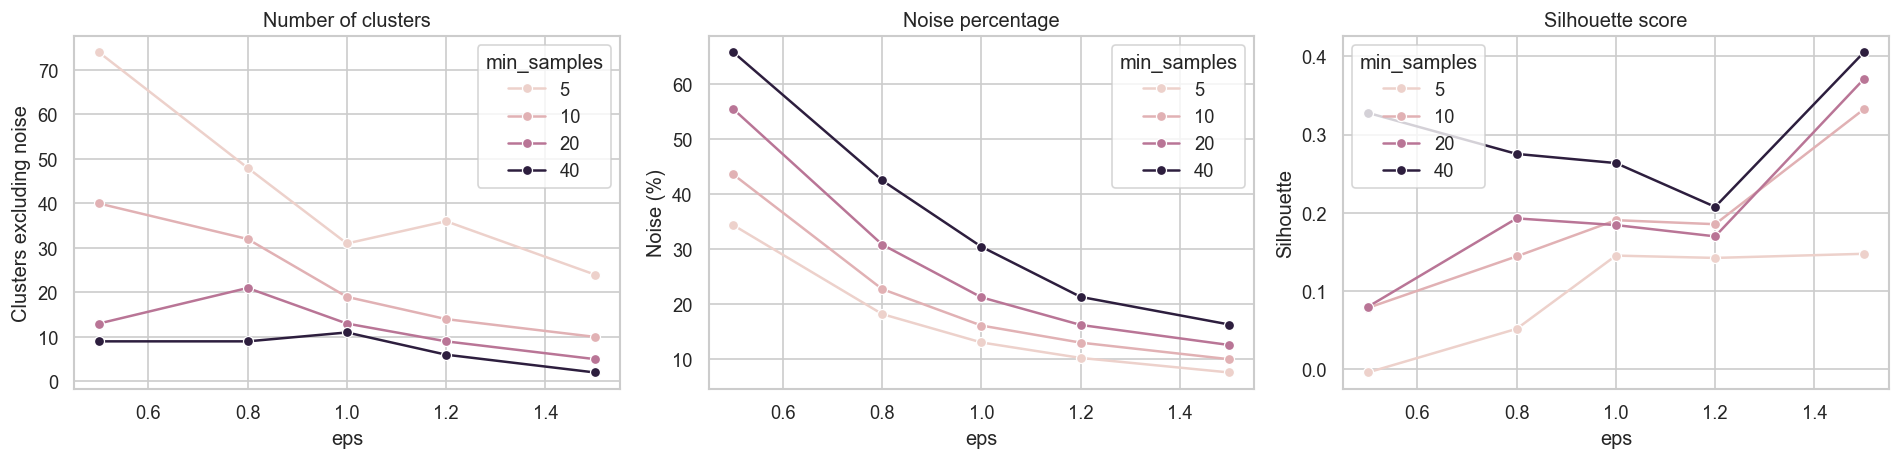

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.lineplot(data=dbscan_results_df, x="eps", y="n_clusters", hue="min_samples", marker="o", ax=axes[0])
axes[0].set_title("Number of clusters")
axes[0].set_ylabel("Clusters excluding noise")

sns.lineplot(data=dbscan_results_df, x="eps", y="noise_pct", hue="min_samples", marker="o", ax=axes[1])
axes[1].set_title("Noise percentage")
axes[1].set_ylabel("Noise (%)")

sns.lineplot(data=dbscan_results_df, x="eps", y="silhouette", hue="min_samples", marker="o", ax=axes[2])
axes[2].set_title("Silhouette score")
axes[2].set_ylabel("Silhouette")

for ax in axes:
    ax.set_xlabel("eps")
    ax.legend(title="min_samples")

plt.tight_layout()
plt.show()


## 9. Select Final DBSCAN Configuration

The final configuration is selected from the tuning grid using these criteria:

- at least two non-noise clusters,
- valid silhouette score,
- noise percentage between 5% and 60%,
- preference for higher silhouette, then lower noise, then fewer clusters for readability.

This avoids choosing a configuration only because it has many tiny clusters or because it excludes too much of the sample as noise.


In [39]:
valid_configs = dbscan_results_df[
    (dbscan_results_df["n_clusters"] >= 2)
    & (dbscan_results_df["noise_pct"].between(5, 60))
    & (dbscan_results_df["silhouette"].notna())
].copy()

if valid_configs.empty:
    raise RuntimeError("No DBSCAN configuration produced at least two clusters with a usable noise percentage and silhouette score.")

selected_row = valid_configs.sort_values(
    ["silhouette", "noise_pct", "n_clusters"],
    ascending=[False, True, True],
).iloc[0]

selected_eps = float(selected_row["eps"])
selected_min_samples = int(selected_row["min_samples"])

print("Selected DBSCAN configuration")
print(f"eps = {selected_eps}")
print(f"min_samples = {selected_min_samples}")
print(f"clusters = {int(selected_row['n_clusters'])}")
print(f"noise = {selected_row['noise_pct']:.2f}%")
print(f"silhouette = {selected_row['silhouette']:.4f}")


Selected DBSCAN configuration
eps = 1.5
min_samples = 40
clusters = 2
noise = 16.22%
silhouette = 0.4053


The selected DBSCAN configuration is the best compromise in the tested grid under the constraints above. It gives a valid silhouette score, keeps the noise percentage in a usable range, and produces a result that can be compared with K-Means on the same subset.


## 10. Cluster Size and Noise Analysis

The selected DBSCAN model is fitted on the same 10,000-row subset. Label `-1` represents noise.


In [40]:
final_dbscan = DBSCAN(eps=selected_eps, min_samples=selected_min_samples, n_jobs=-1)
dbscan_labels = final_dbscan.fit_predict(X_sample_array)
dbscan_summary = summarize_dbscan(dbscan_labels, X_sample_array)

dbscan_cluster_summary = (
    pd.Series(dbscan_labels, name="cluster")
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)
dbscan_cluster_summary["percentage"] = (dbscan_cluster_summary["count"] / len(dbscan_labels) * 100).round(2)

print("Final DBSCAN results")
print(f"Clusters: {dbscan_summary['n_clusters']}")
print(f"Noise points: {dbscan_summary['noise_count']:,}")
print(f"Noise percentage: {dbscan_summary['noise_pct']:.2f}%")
print(f"Silhouette: {dbscan_summary['silhouette']:.4f}" if not np.isnan(dbscan_summary["silhouette"]) else "Silhouette: not valid")

dbscan_cluster_summary


Final DBSCAN results
Clusters: 2
Noise points: 1,622
Noise percentage: 16.22%
Silhouette: 0.4053


,cluster,count,percentage
0,-1,1622,16.22
1,0,8138,81.38
2,1,240,2.40


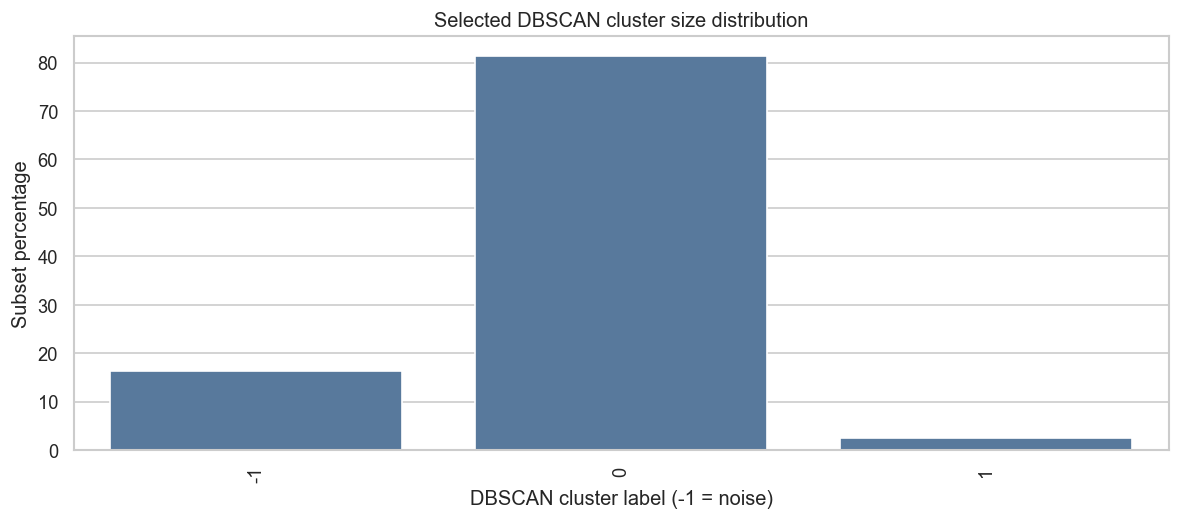

In [41]:
plot_df = dbscan_cluster_summary.copy()
plot_df["cluster"] = plot_df["cluster"].astype(str)

plt.figure(figsize=(10, 4.5))
sns.barplot(data=plot_df, x="cluster", y="percentage", color="#4C78A8")
plt.title("Selected DBSCAN cluster size distribution")
plt.xlabel("DBSCAN cluster label (-1 = noise)")
plt.ylabel("Subset percentage")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 10b. K-Distance Plot and eps Validation

The k-distance plot is the standard graphical method for selecting `eps` in DBSCAN. For a chosen `min_samples`, the distance from each point to its `k`-th nearest neighbor (where `k = min_samples`) is computed, and all distances are sorted in ascending order. The resulting curve is flat in dense regions and rises sharply where the data becomes sparse. The inflection point marks the natural boundary between dense and sparse neighborhoods: choosing `eps` at this elbow minimizes both over-rejection (too many noise points) and over-merging (clusters that are too loose).

The elbow is located geometrically: both axes are normalized to [0, 1], and the point on the curve with the largest perpendicular distance to the diagonal chord connecting the first and last points is taken as the recommended `eps`.

The value retained by the tuning grid (`eps = 1.5`) is compared against this data-driven reference to document where the chosen threshold sits relative to the geometry of the data.

eps at elbow (geometric method): 2.3780
  Elbow percentile in k-distance distribution: 87.5th
  75th percentile of k-distances:              1.4416  (eps=1.5 sits near this level)


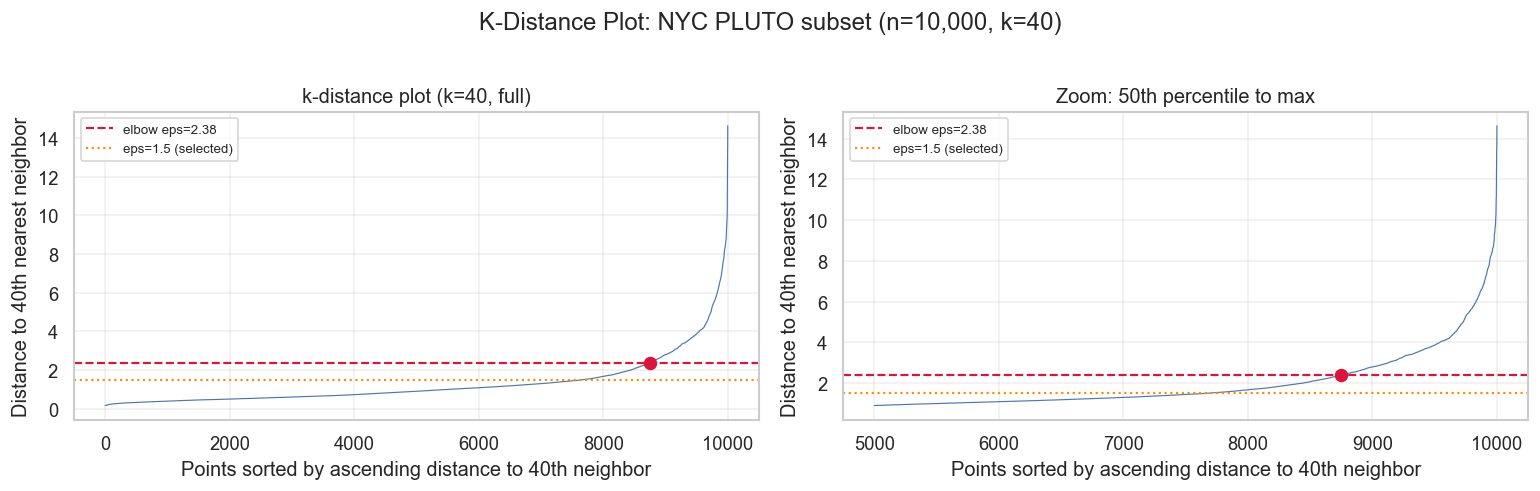

In [42]:
from sklearn.neighbors import NearestNeighbors

_nn = NearestNeighbors(n_neighbors=selected_min_samples, n_jobs=-1)
_nn.fit(X_sample_array)
_kd_raw, _ = _nn.kneighbors(X_sample_array)
kd_sorted = np.sort(_kd_raw[:, -1])   # ascending: k-th nearest-neighbor distance

_n = len(kd_sorted)
_x_norm = np.linspace(0, 1, _n)
_y_norm = (kd_sorted - kd_sorted.min()) / (kd_sorted.max() - kd_sorted.min())
_perp   = np.abs(_y_norm - _x_norm) / np.sqrt(2)
_elbow_idx = int(np.argmax(_perp))
eps_elbow  = float(kd_sorted[_elbow_idx])

_pct_elbow = _elbow_idx / _n * 100
_pct75     = float(np.percentile(kd_sorted, 75))

print(f"eps at elbow (geometric method): {eps_elbow:.4f}")
print(f"  Elbow percentile in k-distance distribution: {_pct_elbow:.1f}th")
print(f"  75th percentile of k-distances:              {_pct75:.4f}  (eps=1.5 sits near this level)")

try:
    from kneed import KneeLocator as _KneeLocator
    _kl = _KneeLocator(np.arange(_n), kd_sorted, curve='convex', direction='increasing')
    if _kl.knee is not None:
        print(f'  kneed cross-check: eps ~= {kd_sorted[int(_kl.knee)]:.4f} (index {_kl.knee})')
except ImportError:
    pass

_zoom = int(_n * 0.50)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, x_vals, y_vals, title in [
    (axes[0], np.arange(_n), kd_sorted,
     f"k-distance plot (k={selected_min_samples}, full)"),
    (axes[1], np.arange(_zoom, _n), kd_sorted[_zoom:],
     "Zoom: 50th percentile to max"),
]:
    ax.plot(x_vals, y_vals, color="#4C78A8", linewidth=0.7)
    ax.axhline(eps_elbow, color='crimson',    linestyle='--', linewidth=1.3,
               label=f"elbow eps={eps_elbow:.2f}")
    ax.axhline(1.5,       color='darkorange', linestyle=':',  linewidth=1.3,
               label="eps=1.5 (selected)")
    if x_vals[0] <= _elbow_idx <= x_vals[-1]:
        ax.scatter([_elbow_idx], [eps_elbow], color='crimson', zorder=5, s=50)
    ax.set_xlabel(f'Points sorted by ascending distance to {selected_min_samples}th neighbor')
    ax.set_ylabel(f'Distance to {selected_min_samples}th nearest neighbor')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"K-Distance Plot: NYC PLUTO subset (n={_n:,}, k={selected_min_samples})", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_dbscan_kdistance.png", bbox_inches="tight")
plt.show()

In [43]:
_db_elbow     = DBSCAN(eps=eps_elbow, min_samples=selected_min_samples, n_jobs=-1)
_labels_elbow = _db_elbow.fit_predict(X_sample_array)
_sum_elbow    = summarize_dbscan(_labels_elbow, X_sample_array)

print(f"DBSCAN at eps={eps_elbow:.4f}, min_samples={selected_min_samples}")
print(f"  Clusters (excl. noise):  {_sum_elbow['n_clusters']}")
print(f"  Noise points:            {_sum_elbow['noise_count']:,} ({_sum_elbow['noise_pct']:.2f}%)")
_sil_str = f"{_sum_elbow['silhouette']:.4f}" if not np.isnan(_sum_elbow['silhouette']) else 'not valid'
print(f"  Silhouette (non-noise):  {_sil_str}")

_elbow_cluster_summary = (
    pd.Series(_labels_elbow, name='cluster')
    .value_counts()
    .sort_index()
    .rename_axis('cluster')
    .reset_index(name='count')
)
_elbow_cluster_summary['percentage'] = (
    _elbow_cluster_summary['count'] / len(_labels_elbow) * 100
).round(2)
_elbow_cluster_summary

DBSCAN at eps=2.3780, min_samples=40
  Clusters (excl. noise):  3
  Noise points:            934 (9.34%)
  Silhouette (non-noise):  0.4187


,cluster,count,percentage
0,-1,934,9.34
1,0,8380,83.80
2,1,526,5.26
3,2,160,1.60


In [44]:
_largest_sel   = dbscan_cluster_summary.loc[
    dbscan_cluster_summary['cluster'] >= 0, 'count'
].max()
_largest_elbow = _elbow_cluster_summary.loc[
    _elbow_cluster_summary['cluster'] >= 0, 'count'
].max()

eps_comparison_df = pd.DataFrame({
    'eps':                 [selected_eps,    round(eps_elbow, 4)],
    'n_clusters':          [dbscan_summary['n_clusters'],    _sum_elbow['n_clusters']],
    'noise_pct':           [round(dbscan_summary['noise_pct'], 2),    round(_sum_elbow['noise_pct'], 2)],
    'silhouette':          [round(dbscan_summary['silhouette'], 4),   round(_sum_elbow['silhouette'], 4)],
    'largest_cluster_pct': [
        round(_largest_sel   / len(dbscan_labels)  * 100, 2),
        round(_largest_elbow / len(_labels_elbow) * 100, 2),
    ],
})
eps_comparison_df

,eps,n_clusters,noise_pct,silhouette,largest_cluster_pct
0,1.500,2,16.22,0.4053,81.38
1,2.378,3,9.34,0.4187,83.80


The k-distance plot places the natural eps threshold at approximately 2.38, corresponding to the 87.5th percentile of k-distances for `k=40`. The tuning grid retained `eps=1.5`, which sits near the 75th percentile and applies a stricter density requirement.

At the elbow (`eps ≈ 2.38`), DBSCAN finds three clusters instead of two. The structure remains highly asymmetric: one dominant cluster contains roughly 84% of the subset, and two smaller pockets account for the rest. Around 700 buildings labeled as noise at `eps=1.5` resolve into these dense pockets at the elbow value, indicating that the stricter threshold classifies genuinely dense observations as noise.

The main two-group macro-partition is robust beyond the elbow: the dominant split between a large residential-morphology group and a smaller mixed-use group persists at both thresholds. A finer sub-structure becomes visible at `eps=2.38`, but it does not alter the macro interpretation.

`eps=1.5` is kept for the K-Means comparison in the next section because it yields the cleanest two-cluster alignment, matching K-Means's forced bipartition. The elbow value of approximately 2.38 is documented here as the geometrically grounded reference derived from the data.

## 11. K-Means vs DBSCAN Comparison on the Exact Same Subset

The comparison uses the exact same `X_sample` for both algorithms.

If Elie's saved K-Means labels in `cluster_labels.csv` match the shared sample, this notebook loads the corresponding labels for the selected 10,000 rows. If not, it reruns K-Means on the same subset using `random_state=42` and `k=2`, which is the primary final `k` documented by Elie's validated notebook/results.


In [45]:
FINAL_K = 2
loaded_kmeans_labels = False

if KMEANS_LABELS_PATH.exists() and SHARED_SAMPLE_INDEX_PATH.exists():
    saved_labels = pd.read_csv(KMEANS_LABELS_PATH, index_col=0)
    shared_sample_idx_for_labels = pd.read_csv(SHARED_SAMPLE_INDEX_PATH).iloc[:, 0].astype(int).to_numpy()
    if "cluster" in saved_labels.columns and np.array_equal(saved_labels.index.astype(int).to_numpy(), shared_sample_idx_for_labels):
        kmeans_labels = saved_labels.iloc[selected_positions]["cluster"].astype(int).to_numpy()
        loaded_kmeans_labels = True
        kmeans_source = "loaded from Elie's cluster_labels.csv and subset to the same rows"
    else:
        kmeans_source = "rerun because saved K-Means labels did not match sample_index.csv"
else:
    kmeans_source = "rerun because saved K-Means labels were not available"

if not loaded_kmeans_labels:
    kmeans_model = KMeans(
        n_clusters=FINAL_K,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE,
    )
    kmeans_labels = kmeans_model.fit_predict(X_sample_array)

kmeans_silhouette = silhouette_score(
    X_sample_array,
    kmeans_labels,
    sample_size=min(SILHOUETTE_SAMPLE_SIZE, len(X_sample_array)),
    random_state=RANDOM_STATE,
)

comparison_df = pd.DataFrame({
    "algorithm": ["K-Means", "DBSCAN"],
    "clusters": [len(np.unique(kmeans_labels)), dbscan_summary["n_clusters"]],
    "noise_pct": [0.0, round(dbscan_summary["noise_pct"], 2)],
    "silhouette": [kmeans_silhouette, dbscan_summary["silhouette"]],
    "subset_size": [len(X_sample_array), len(X_sample_array)],
})

print(f"K-Means labels: {kmeans_source}")
comparison_df


K-Means labels: loaded from Elie's cluster_labels.csv and subset to the same rows


,algorithm,clusters,noise_pct,silhouette,subset_size
0,K-Means,2,0.00,0.468043,10000
1,DBSCAN,2,16.22,0.405339,10000


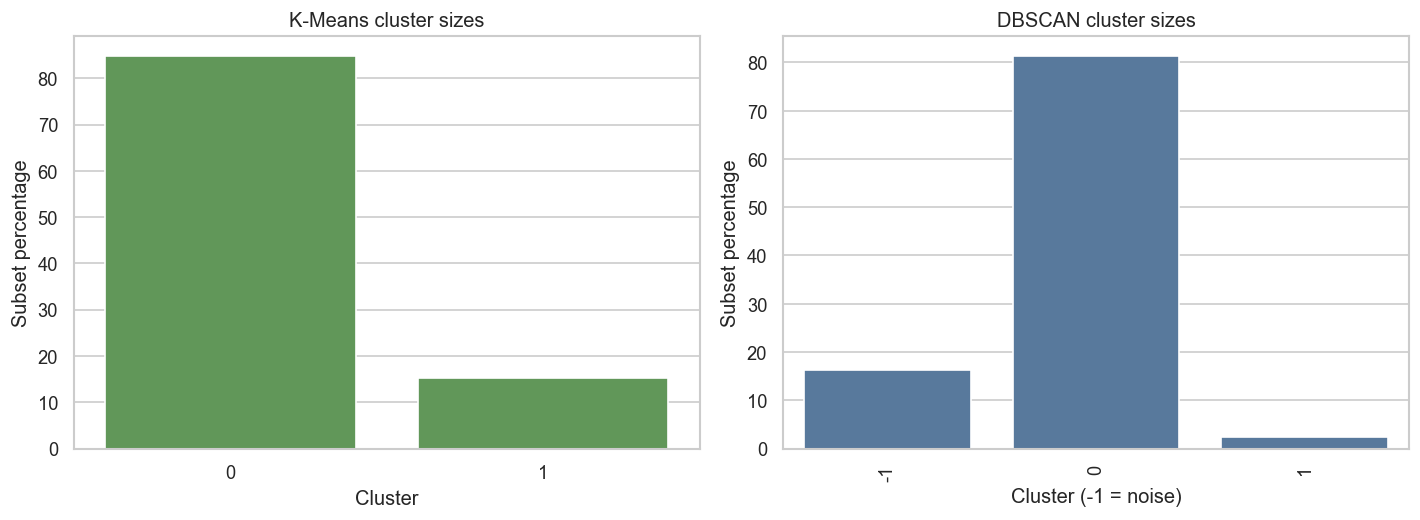

In [46]:
kmeans_cluster_summary = (
    pd.Series(kmeans_labels, name="cluster")
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)
kmeans_cluster_summary["percentage"] = (kmeans_cluster_summary["count"] / len(kmeans_labels) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(data=kmeans_cluster_summary.assign(cluster=lambda d: d["cluster"].astype(str)), x="cluster", y="percentage", color="#59A14F", ax=axes[0])
axes[0].set_title("K-Means cluster sizes")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Subset percentage")

sns.barplot(data=plot_df, x="cluster", y="percentage", color="#4C78A8", ax=axes[1])
axes[1].set_title("DBSCAN cluster sizes")
axes[1].set_xlabel("Cluster (-1 = noise)")
axes[1].set_ylabel("Subset percentage")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


In [47]:
# Save shared subset labels for the visualization notebook.
DBSCAN_KMEANS_LABELS_PATH = PROCESSED_DIR / "dbscan_kmeans_sample_labels.csv"
DBSCAN_SELECTION_SUMMARY_PATH = PROCESSED_DIR / "dbscan_selection_summary.csv"

pd.DataFrame({
    "row_index": sample_idx,
    "dbscan_cluster": dbscan_labels,
    "kmeans_cluster": kmeans_labels,
}).to_csv(DBSCAN_KMEANS_LABELS_PATH, index=False)

pd.DataFrame([{
    "eps": selected_eps,
    "min_samples": selected_min_samples,
    "n_clusters": dbscan_summary["n_clusters"],
    "noise_pct": dbscan_summary["noise_pct"],
    "dbscan_silhouette": dbscan_summary["silhouette"],
    "kmeans_silhouette": kmeans_silhouette,
}]).to_csv(DBSCAN_SELECTION_SUMMARY_PATH, index=False)

print(f"Saved subset labels to {DBSCAN_KMEANS_LABELS_PATH.relative_to(PROJECT_ROOT)}")
print(f"Saved selection summary to {DBSCAN_SELECTION_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")

Saved subset labels to data/processed/dbscan_kmeans_sample_labels.csv
Saved selection summary to data/processed/dbscan_selection_summary.csv


**Comparison interpretation:** K-Means assigns every point to one of the selected clusters, while DBSCAN can mark atypical points as noise. Therefore, DBSCAN's silhouette score must be interpreted together with its noise percentage.


## 12. Answers to Professor Questions Assigned to Alon

### Q3.1 - Example Where Euclidean Distance Is Not Natural

Euclidean distance is not natural for comparing mixed urban objects when numeric closeness does not mean functional similarity. For example, two buildings may have similar lot area and floor area but completely different land-use roles, or two neighborhoods may be geographically close but socio-economically different. Euclidean distance also becomes problematic when features are correlated or high-dimensional.

### Q6.1 - Main Idea Behind DBSCAN

DBSCAN finds clusters as dense regions separated by sparse regions. Points inside dense neighborhoods become core points, nearby points join those clusters, and isolated points are labeled as noise.

### Q6.2 - Dataset Where DBSCAN Performs Well

DBSCAN performs well for irregularly shaped clusters with natural outliers, such as GPS points along roads or pedestrian paths. The clusters do not need to be spherical, and the number of clusters does not need to be known in advance.

### Q6.3 - Dataset Where DBSCAN May Fail

DBSCAN may fail when clusters have very different densities. One global `eps` can be too small for sparse clusters and too large for dense clusters. This is relevant for PLUTO because dense areas and low-density areas may need different neighborhood radii.

### Q6.6 - Noise Point in the Toy Example

With `eps=0.5` and `min_samples=3`, the point `[8.0, 1.0]` is labeled as noise because it is not within the required dense neighborhood of either compact group.

### Q6.7 - How Labels Change When `eps` Changes

In the tested toy example values `eps=0.3`, `0.5`, `1.0`, and `3.0`, the labels do not change. The two compact groups remain separate clusters and `[8.0, 1.0]` remains noise. We should not claim merging or absorption unless a larger tested `eps` actually shows that behavior.

### Q9.1 - Why the Curse of Dimensionality Affects K-Means and DBSCAN

In high-dimensional data, distances become less informative because points tend to appear similarly far apart. K-Means is affected because centroids become less representative and cluster boundaries become less meaningful. DBSCAN is affected because choosing `eps` becomes difficult: a radius may include almost no points or too many points. Standardizing and limiting the feature set helps, but distance-based clustering still becomes harder as dimensionality grows.


## 13. Short Conclusion

Alon's notebook uses Elie's validated preprocessing output, applies DBSCAN to a reproducible 10,000-row subset, tunes `eps` and `min_samples`, reports cluster/noise/silhouette behavior, and compares DBSCAN with K-Means on the exact same rows. DBSCAN adds a density-based view of the data and identifies noise points, while K-Means provides full coverage of the subset.


# Part 3 - Ouri Ouahba - Clustering Visualization and Final Synthesis

## 2. Load Data and Existing Outputs

This section loads Elie's final standardized matrix and the available clustering labels. If Alon's DBSCAN labels are not available, only the final DBSCAN model is recomputed with `eps=1.5` and `min_samples=40` on the exact same working subset.


In [48]:
# Alias so the Load Data section below can use the original variable name.
ALON_LABELS_PATH = DBSCAN_KMEANS_LABELS_PATH

# Load clustering metrics from Alon's saved summary when available; fall back to
# the values that were current when this notebook was last verified otherwise.
_FALLBACK_KMEANS_SIL = 0.4680
_FALLBACK_DBSCAN_SIL = 0.4053
_FALLBACK_EPS = 1.5
_FALLBACK_MIN_SAMPLES = 40
_FALLBACK_NOISE_PCT = 16.22

if DBSCAN_SELECTION_SUMMARY_PATH.exists():
    _summary = pd.read_csv(DBSCAN_SELECTION_SUMMARY_PATH).iloc[0]
    KMEANS_SILHOUETTE_USED = float(_summary["kmeans_silhouette"])
    DBSCAN_SILHOUETTE_USED = float(_summary["dbscan_silhouette"])
    DBSCAN_EPS = float(_summary["eps"])
    DBSCAN_MIN_SAMPLES = int(_summary["min_samples"])
    DBSCAN_NOISE_PCT = float(_summary["noise_pct"])
    print("Loaded clustering metrics from dbscan_selection_summary.csv")
else:
    KMEANS_SILHOUETTE_USED = _FALLBACK_KMEANS_SIL
    DBSCAN_SILHOUETTE_USED = _FALLBACK_DBSCAN_SIL
    DBSCAN_EPS = _FALLBACK_EPS
    DBSCAN_MIN_SAMPLES = _FALLBACK_MIN_SAMPLES
    DBSCAN_NOISE_PCT = _FALLBACK_NOISE_PCT
    print("Warning: dbscan_selection_summary.csv not found - using fallback metric values.")

if not X_SCALED_PATH.exists():
    raise FileNotFoundError(f"Missing {X_SCALED_PATH}. Run Elie's preprocessing notebook first.")

X_scaled = pd.read_csv(X_SCALED_PATH)

if FEATURES_PATH.exists():
    feature_names = pd.read_csv(FEATURES_PATH)["feature"].tolist()
    if len(feature_names) == X_scaled.shape[1]:
        X_scaled.columns = feature_names
else:
    feature_names = list(X_scaled.columns)

rng = np.random.RandomState(RANDOM_STATE)
labels_source = []

# Prefer Alon's saved comparison labels if available; they already encode the exact 10,000-row subset.
if ALON_LABELS_PATH.exists():
    alon_labels = pd.read_csv(ALON_LABELS_PATH)
    required_cols = {"row_index", "dbscan_cluster", "kmeans_cluster"}
    if required_cols.issubset(alon_labels.columns):
        sample_idx = alon_labels["row_index"].astype(int).to_numpy()
        kmeans_labels = alon_labels["kmeans_cluster"].astype(int).to_numpy()
        dbscan_labels = alon_labels["dbscan_cluster"].astype(int).to_numpy()
        labels_source.append("Loaded DBSCAN and K-Means subset labels from Alon's dbscan_kmeans_sample_labels.csv")
    else:
        raise ValueError(f"{ALON_LABELS_PATH.name} exists but does not contain {required_cols}.")
else:
    # Recreate Alon's deterministic 10,000-row subset from the shared 50,000-row sample when possible.
    if SAMPLE_INDEX_PATH.exists():
        shared_sample_idx = pd.read_csv(SAMPLE_INDEX_PATH).iloc[:, 0].astype(int).to_numpy()
        selected_positions = rng.choice(len(shared_sample_idx), size=min(SAMPLE_SIZE, len(shared_sample_idx)), replace=False)
        sample_idx = shared_sample_idx[selected_positions]
        labels_source.append("Recreated the 10,000-row subset from sample_index.csv with random_state=42")
    else:
        sample_idx = rng.choice(X_scaled.index.to_numpy(), size=min(SAMPLE_SIZE, len(X_scaled)), replace=False)
        selected_positions = None
        labels_source.append("Recreated the 10,000-row subset directly from X_scaled with random_state=42")

    if KMEANS_LABELS_PATH.exists() and SAMPLE_INDEX_PATH.exists():
        saved_kmeans = pd.read_csv(KMEANS_LABELS_PATH, index_col=0)
        shared_sample_idx_for_labels = pd.read_csv(SAMPLE_INDEX_PATH).iloc[:, 0].astype(int).to_numpy()
        if "cluster" in saved_kmeans.columns and np.array_equal(saved_kmeans.index.astype(int).to_numpy(), shared_sample_idx_for_labels):
            kmeans_lookup = saved_kmeans["cluster"].astype(int)
            kmeans_labels = kmeans_lookup.loc[sample_idx].to_numpy()
            labels_source.append("Loaded K-Means labels from Elie's cluster_labels.csv")
        else:
            raise ValueError("K-Means labels exist but are not compatible with sample_index.csv.")
    else:
        raise FileNotFoundError("K-Means labels are required from Elie's output for Ouri's notebook.")

    X_for_dbscan = X_scaled.iloc[sample_idx].to_numpy(dtype=np.float32)
    dbscan_labels = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES, n_jobs=-1).fit_predict(X_for_dbscan)
    labels_source.append("Recomputed final DBSCAN labels only, using eps=1.5 and min_samples=40")

if len(sample_idx) != SAMPLE_SIZE:
    print(f"Warning: working subset has {len(sample_idx):,} rows instead of {SAMPLE_SIZE:,}.")
if sample_idx.min() < 0 or sample_idx.max() >= len(X_scaled):
    raise ValueError("Working subset contains row positions outside X_scaled.")

X_sample = X_scaled.iloc[sample_idx].copy()
X_sample_array = X_sample.to_numpy(dtype=np.float32)

companion = pd.read_csv(COMPANION_PATH) if COMPANION_PATH.exists() else None
if companion is not None:
    companion_sample = companion.iloc[sample_idx].copy()
else:
    companion_sample = None

for item in labels_source:
    print("-", item)
print(f"Loaded X_scaled: {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} features")
print(f"Working subset: {len(sample_idx):,} rows")


Loaded clustering metrics from dbscan_selection_summary.csv


- Loaded DBSCAN and K-Means subset labels from Alon's dbscan_kmeans_sample_labels.csv
Loaded X_scaled: 682,515 rows x 16 features
Working subset: 10,000 rows


## 3. Consistency Check

Both algorithms are compared on the same working subset, so the comparison is coherent.


In [49]:
consistency_df = pd.DataFrame({
    "item": [
        "X_scaled shape",
        "working subset size",
        "number of K-Means labels",
        "number of DBSCAN labels",
        "K-Means silhouette score used",
        "DBSCAN silhouette score used",
    ],
    "value": [
        str(X_scaled.shape),
        len(X_sample),
        len(kmeans_labels),
        len(dbscan_labels),
        f"{KMEANS_SILHOUETTE_USED:.4f}",
        f"{DBSCAN_SILHOUETTE_USED:.4f}",
    ],
})
consistency_df


,item,value
0,X_scaled shape,"(682515, 16)"
1,working subset size,10000
2,number of K-Means labels,10000
3,number of DBSCAN labels,10000
4,K-Means silhouette score used,0.4680
5,DBSCAN silhouette score used,0.4053


## 4. PCA Projection for Visualization

PCA is used only to project the high-dimensional data into two dimensions for visualization. It is not used as a clustering algorithm.


In [50]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_sample_array)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "KMeans label": kmeans_labels.astype(int),
    "DBSCAN label": dbscan_labels.astype(int),
})
pca_df["DBSCAN noise"] = pca_df["DBSCAN label"] == -1

explained_variance = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca_2d.explained_variance_ratio_,
})
explained_variance


,component,explained_variance_ratio
0,PC1,0.239785
1,PC2,0.194704


## 5. K-Means Clusters Visualized with PCA

K-Means uses `k=2` and assigns every observation to one of the two clusters.
Its silhouette score is `0.4680`, which reflects strong separation in the full
16-dimensional feature space.

**Reading the PCA plot:** the scatter appears to contain three distinct groups despite
having only two colors. This is expected and not a contradiction. One of the two K-Means
clusters has a bimodal projection onto PC1 and PC2: its two sub-clouds are connected
through dimensions 3 to 16 that the 2D plot does not capture. The apparent third group
is therefore a portion of an existing cluster, not an independent structure.

This visual pattern is the 2D echo of the elbow signal computed in Section 8a: the
second-difference curvature of the inertia curve peaks at k=3, indicating that one
macro-cluster contains a separable sub-group. k=2 remains the statistically supported
choice; the sub-structure is real but weaker than the primary binary divide.


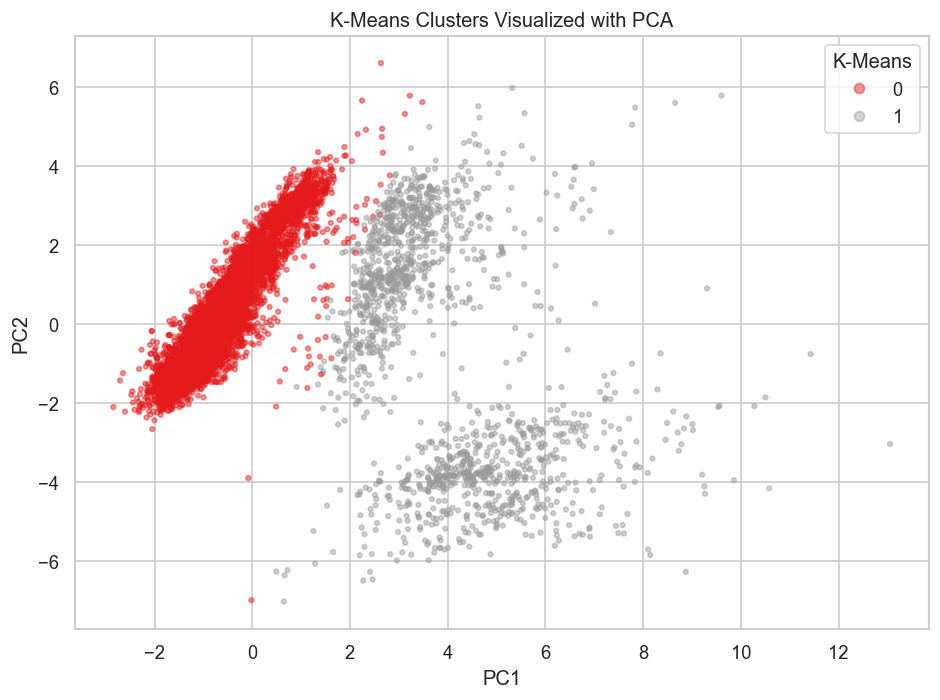

In [51]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["KMeans label"],
    s=8,
    alpha=0.45,
    cmap="Set1",
)
plt.title("K-Means Clusters Visualized with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(*scatter.legend_elements(), title="K-Means")
plt.tight_layout()
plt.show()


## 6. DBSCAN Clusters and Noise Visualized with PCA

DBSCAN uses `eps=1.5` and `min_samples=40`. It found 2 clusters, marks `16.22%` of points as noise, and has silhouette score `0.4053`. DBSCAN is useful because it does not force every point into a cluster and can identify atypical observations.


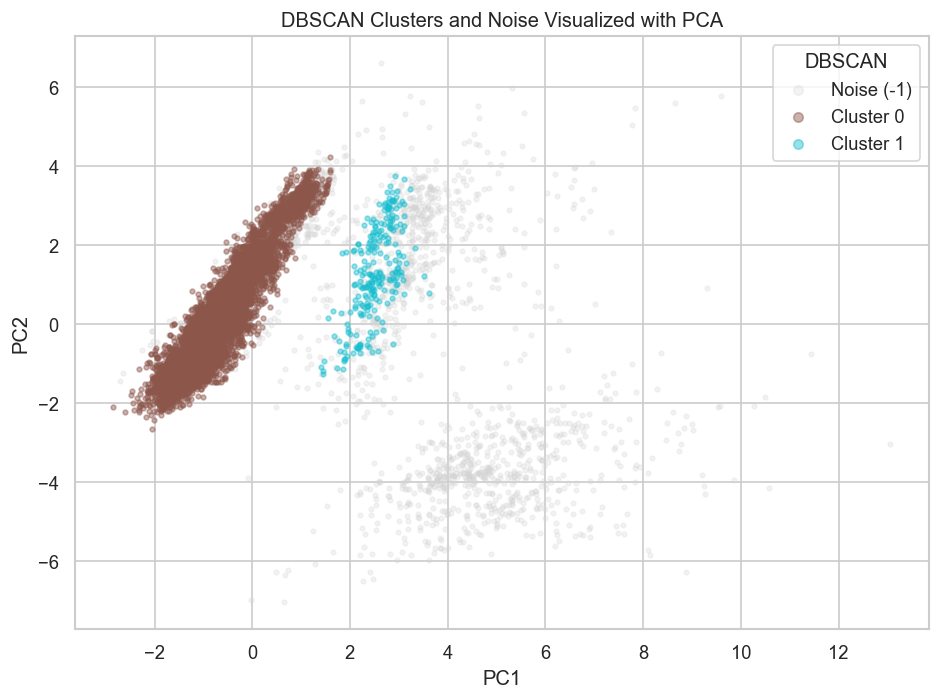

In [52]:
plt.figure(figsize=(8, 6))
unique_labels = sorted(pca_df["DBSCAN label"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 2)))

for color, label in zip(colors, unique_labels):
    mask = pca_df["DBSCAN label"] == label
    if label == -1:
        plt.scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"], s=8, alpha=0.25, c="lightgray", label="Noise (-1)")
    else:
        plt.scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"], s=8, alpha=0.45, color=color, label=f"Cluster {label}")

plt.title("DBSCAN Clusters and Noise Visualized with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="DBSCAN", markerscale=2)
plt.tight_layout()
plt.show()


## 7. Individual Silhouette Plots

Silhouette values close to 1 indicate well-separated clusters. Values around 0 indicate overlap. Negative values may indicate poor assignment.

For DBSCAN, noise points (`-1`) are excluded from the silhouette plot because silhouette evaluates assigned clusters. This matches Alon's approach for DBSCAN silhouette reporting.


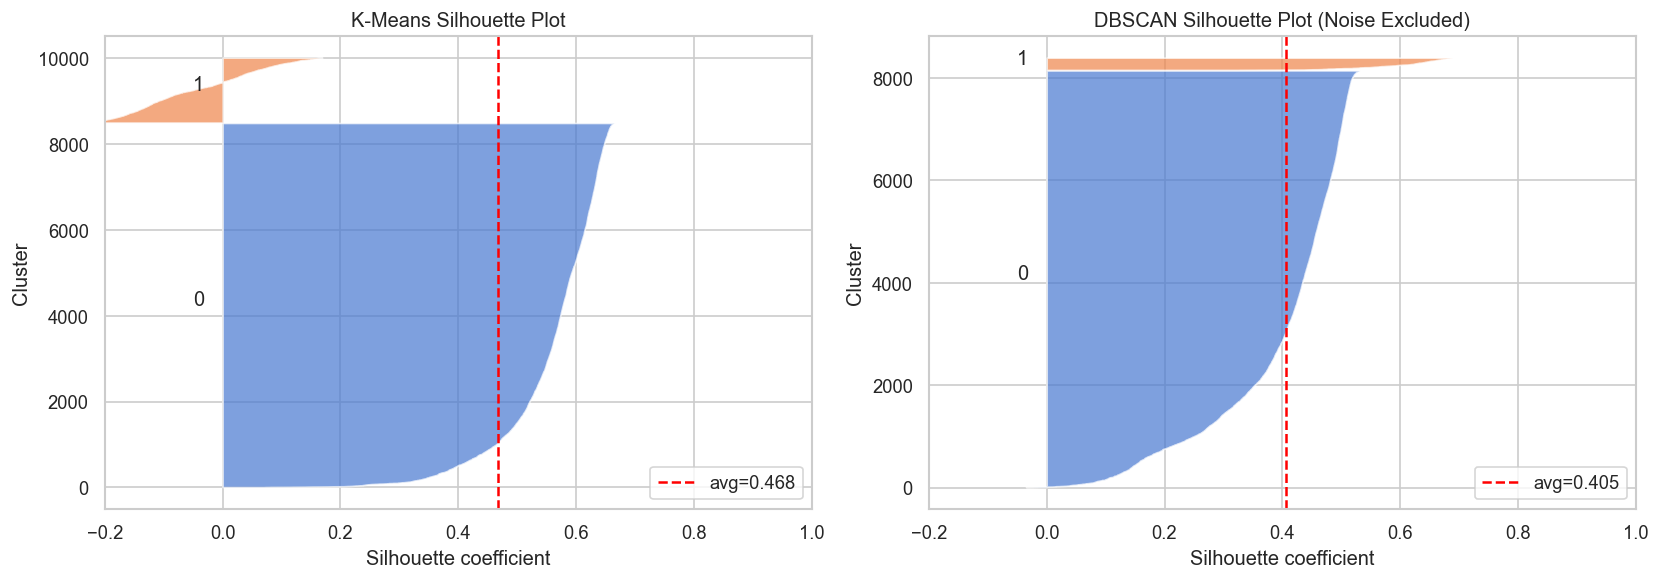

,algorithm,reported_silhouette,plot_silhouette
0,K-Means,0.468043,0.468043
1,DBSCAN,0.405339,0.405339


In [53]:
def plot_silhouette(ax, X, labels, title, exclude_noise=False):
    labels = np.asarray(labels)
    if exclude_noise:
        mask = labels != -1
        X_plot = X[mask]
        labels_plot = labels[mask]
    else:
        X_plot = X
        labels_plot = labels

    n_clusters = len(set(labels_plot))
    if len(labels_plot) < 3 or n_clusters < 2:
        ax.text(0.5, 0.5, "Silhouette is not valid", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return np.nan

    values = silhouette_samples(X_plot, labels_plot)
    avg_score = silhouette_score(X_plot, labels_plot, sample_size=min(SILHOUETTE_SAMPLE_SIZE, len(X_plot)), random_state=RANDOM_STATE)

    y_lower = 10
    for cluster_label in sorted(set(labels_plot)):
        cluster_values = np.sort(values[labels_plot == cluster_label])
        size = len(cluster_values)
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_values, alpha=0.7)
        ax.text(-0.05, y_lower + size / 2, str(cluster_label))
        y_lower = y_upper + 10

    ax.axvline(avg_score, color="red", linestyle="--", linewidth=1.5, label=f"avg={avg_score:.3f}")
    ax.set_title(title)
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.set_xlim([-0.2, 1.0])
    ax.legend(loc="lower right")
    return avg_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
kmeans_sil_plot = plot_silhouette(axes[0], X_sample_array, kmeans_labels, "K-Means Silhouette Plot")
dbscan_sil_plot = plot_silhouette(axes[1], X_sample_array, dbscan_labels, "DBSCAN Silhouette Plot (Noise Excluded)", exclude_noise=True)
plt.tight_layout()
plt.show()

pd.DataFrame({
    "algorithm": ["K-Means", "DBSCAN"],
    "reported_silhouette": [KMEANS_SILHOUETTE_USED, DBSCAN_SILHOUETTE_USED],
    "plot_silhouette": [kmeans_sil_plot, dbscan_sil_plot],
})


K-Means has silhouette score `0.4680`, while DBSCAN has silhouette score `0.4053`. According to silhouette score alone, K-Means is slightly stronger on the shared subset. DBSCAN remains useful because it separates dense groups while leaving atypical observations as noise.


## 8. K-Means Centroid Heatmap

If saved centroids are not available, centroids are computed from the scaled feature matrix by taking the mean of each scaled feature within each K-Means cluster. The heatmap shows the most differentiated features between the two centroids.


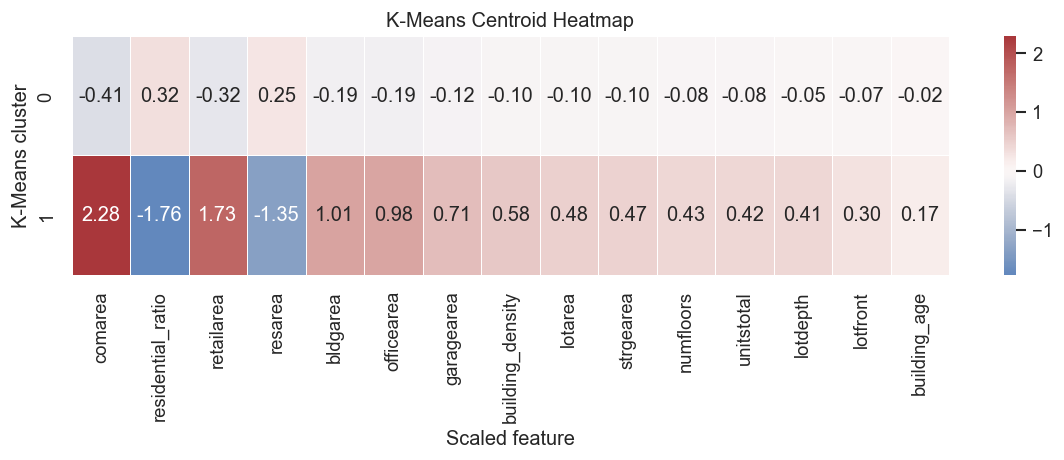

,comarea,residential_ratio,retailarea,resarea,bldgarea,officearea,garagearea,building_density,lotarea,strgearea,numfloors,unitstotal,lotdepth,lotfront,building_age
cluster,,,,,,,,,,,,,,,
0,-0.412,0.324,-0.318,0.254,-0.186,-0.194,-0.120,-0.099,-0.098,-0.100,-0.083,-0.079,-0.052,-0.070,-0.016
1,2.280,-1.761,1.730,-1.353,1.006,0.978,0.715,0.579,0.481,0.472,0.426,0.422,0.406,0.296,0.166


In [54]:
centroids_scaled = X_sample.assign(cluster=kmeans_labels).groupby("cluster").mean(numeric_only=True)
feature_range = (centroids_scaled.max(axis=0) - centroids_scaled.min(axis=0)).abs()
selected_features = feature_range.sort_values(ascending=False).head(min(15, len(feature_range))).index.tolist()

plt.figure(figsize=(10, 4))
sns.heatmap(
    centroids_scaled[selected_features],
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
)
plt.title("K-Means Centroid Heatmap")
plt.xlabel("Scaled feature")
plt.ylabel("K-Means cluster")
plt.tight_layout()
plt.show()

centroids_scaled[selected_features].round(3)


The centroid heatmap should be read cautiously because values are standardized. Positive values indicate that a cluster is above the sample average for that feature, while negative values indicate below-average values. The most useful interpretation comes from comparing clusters feature by feature rather than treating the values as original units.


## 9. K-Means Cluster Profile Interpretation

This section uses original interpretable columns from `pluto_companion.csv` when available. These values are easier to interpret than standardized centroids.


In [55]:
if companion_sample is None:
    profile_summary = pd.DataFrame({"message": ["pluto_companion.csv was not available, so original feature profiles could not be computed."]})
else:
    profile_cols = [
        "lotarea", "bldgarea", "numfloors", "unitstotal", "unitsres",
        "resarea", "comarea", "building_age", "building_density", "residential_ratio",
    ]
    profile_cols = [c for c in profile_cols if c in companion_sample.columns]
    profile_data = companion_sample.copy()
    profile_data["KMeans cluster"] = kmeans_labels

    rows = []
    for cluster_label, group in profile_data.groupby("KMeans cluster"):
        row = {
            "cluster": int(cluster_label),
            "count": len(group),
            "percentage": round(len(group) / len(profile_data) * 100, 2),
        }
        for col in profile_cols:
            row[f"median_{col}"] = round(group[col].median(), 3)
        if "borough" in group.columns:
            row["main_borough"] = group["borough"].mode(dropna=True).iloc[0]
        if "landuse" in group.columns:
            row["main_landuse"] = group["landuse"].mode(dropna=True).iloc[0]
        rows.append(row)

    profile_summary = pd.DataFrame(rows).sort_values("cluster")

    if "median_bldgarea" in profile_summary.columns:
        high_intensity_cluster = profile_summary.sort_values("median_bldgarea").iloc[-1]["cluster"]
    else:
        high_intensity_cluster = profile_summary.sort_values("count").iloc[-1]["cluster"]

    profile_summary["profile_name"] = np.where(
        profile_summary["cluster"] == high_intensity_cluster,
        "Larger or higher-intensity buildings",
        "Typical lower-intensity buildings",
    )

profile_summary


,cluster,count,percentage,median_lotarea,median_bldgarea,median_numfloors,median_unitstotal,median_unitsres,median_resarea,median_comarea,median_building_age,median_building_density,median_residential_ratio,main_borough,main_landuse,profile_name
0,0,8487,84.87,2500.0,2050.0,2.0,2.0,2.0,1862.0,0.0,91.0,0.799,1.0,BK,1.0,Typical lower-intensity buildings
1,1,1513,15.13,3258.0,5164.0,3.0,3.0,1.0,1155.0,2500.0,95.0,1.010,0.5,BK,4.0,Larger or higher-intensity buildings


The two K-Means profiles are intentionally named cautiously. If the original feature medians show that one cluster has larger building area, more units, or higher density, it can reasonably be described as a larger or higher-intensity building group. The other cluster is better interpreted as the more typical lower-intensity group. These profiles make sense for NYC buildings because the city contains both many ordinary small residential lots and a smaller set of larger or more intensive properties.


## 10. DBSCAN Noise Interpretation

Noise points are not necessarily errors. They are observations that DBSCAN does not place in dense regions. They may represent atypical buildings or unusual combinations of features.


In [56]:
if companion_sample is None:
    dbscan_noise_summary = pd.DataFrame({"message": ["pluto_companion.csv was not available, so original feature noise profiles could not be computed."]})
else:
    noise_data = companion_sample.copy()
    noise_data["DBSCAN group"] = np.where(dbscan_labels == -1, "noise", "non-noise")
    rows = []
    for group_label, group in noise_data.groupby("DBSCAN group"):
        row = {
            "group": group_label,
            "count": len(group),
            "percentage": round(len(group) / len(noise_data) * 100, 2),
        }
        for col in profile_cols:
            row[f"median_{col}"] = round(group[col].median(), 3)
        rows.append(row)
    dbscan_noise_summary = pd.DataFrame(rows)

dbscan_noise_summary


,group,count,percentage,median_lotarea,median_bldgarea,median_numfloors,median_unitstotal,median_unitsres,median_resarea,median_comarea,median_building_age,median_building_density,median_residential_ratio
0,noise,1622,16.22,4007.0,5592.5,3.0,3.0,1.0,1360.0,2150.5,95.0,0.980,0.667
1,non-noise,8378,83.78,2458.0,2048.0,2.0,2.0,2.0,1840.0,0.0,91.0,0.799,1.000


The noise summary compares observations assigned to DBSCAN clusters with observations left as noise. Differences in medians can suggest what kinds of buildings DBSCAN considers atypical, but this should not be interpreted as proof of data errors.


## 11. K-Means vs DBSCAN Comparison Table

This table harmonizes the terminology used across the project and summarizes the practical trade-off between the two clustering algorithms.


In [57]:
comparison_table = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN"],
    "Main parameters": ["k=2", f"eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES}"],
    "Number of clusters": [2, 2],
    "Noise percentage": ["0%", f"{DBSCAN_NOISE_PCT:.2f}%"],
    "Silhouette score": [f"{KMEANS_SILHOUETTE_USED:.4f}", f"{DBSCAN_SILHOUETTE_USED:.4f}"],
    "Main interpretation": [
        "Better silhouette, stable and easier to interpret, assigns all points.",
        "Slightly weaker silhouette, but useful for detecting atypical/noise observations.",
    ],
})
comparison_table

,Algorithm,Main parameters,Number of clusters,Noise percentage,Silhouette score,Main interpretation
0,K-Means,k=2,2,0%,0.4680,"Better silhouette, stable and easier to interp..."
1,DBSCAN,"eps=1.5, min_samples=40",2,16.22%,0.4053,"Slightly weaker silhouette, but useful for det..."


## 12. Optional Hierarchical Dendrogram

This section uses only the professor's six-point example, so it runs quickly. It does not run hierarchical clustering on the 10,000-row PLUTO subset.


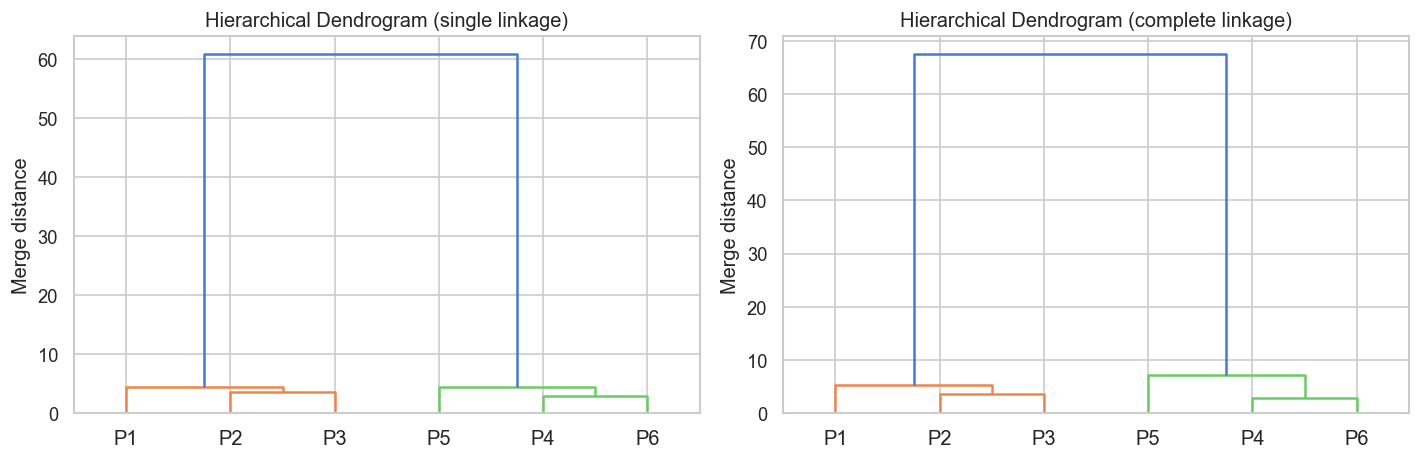

In [58]:
X_hier = np.array([
    [25, 30],
    [27, 35],
    [29, 32],
    [70, 80],
    [72, 76],
    [68, 82],
], dtype=float)
point_labels = ["P1", "P2", "P3", "P4", "P5", "P6"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, method in zip(axes, ["single", "complete"]):
    Z = linkage(X_hier, method=method)
    dendrogram(Z, labels=point_labels, ax=ax)
    ax.set_title(f"Hierarchical Dendrogram ({method} linkage)")
    ax.set_ylabel("Merge distance")
plt.tight_layout()
plt.show()


## 13. Answers to Section 5 Questions - Hierarchical Clustering

### Q5.1. How does hierarchical clustering differ conceptually from K-Means?

K-Means requires choosing the number of clusters `k` in advance and directly partitions the data into `k` groups around centroids. Hierarchical clustering builds a tree of merges, called a dendrogram, starting from individual points and progressively merging clusters. It does not require choosing the final number of clusters at the beginning; we can choose it later by cutting the dendrogram.

### Q5.2. What is the difference between single linkage and complete linkage?

Single linkage defines the distance between two clusters as the minimum distance between any point in one cluster and any point in the other cluster. Complete linkage defines it as the maximum distance between points from the two clusters. Single linkage can create long chain-like clusters, while complete linkage tends to produce more compact clusters.

### Q5.3. In what sense can average linkage be viewed as a compromise between single and complete linkage?

Average linkage uses the average distance between all pairs of points across two clusters. It is a compromise because it does not depend only on the closest pair, like single linkage, and it does not depend only on the farthest pair, like complete linkage. It gives a more balanced measure of distance between clusters.

### Q5.4. What information does a dendrogram provide?

A dendrogram shows the order in which clusters are merged and the height at which each merge occurs. The height represents how dissimilar the merged clusters are. By cutting the dendrogram at a chosen height, we obtain a chosen number of clusters.

### Q5.5. In the professor's coding exercise, replacing `method='single'` with `method='complete'`: how does the dendrogram change?

With single linkage, clusters may merge based on only the closest pair of points, which can create chaining effects. With complete linkage, clusters merge only when all points are relatively close, so the dendrogram tends to show more compact and separated groups. In the small example, both methods still reveal two natural groups, but the merge heights and structure differ.

### Q5.6. In the professor's small example, does hierarchical clustering suggest a natural split into two clusters?

Yes. The first three points are close to one another and the last three points are close to one another, while the distance between these two groups is much larger. The dendrogram therefore suggests a natural split into two clusters.


## 14. Final Synthesis Conclusion

The project uses two clustering algorithms: K-Means and DBSCAN. This satisfies the mini-project requirement of comparing clustering algorithms.

K-Means gives the better silhouette score on the shared subset: `0.4680`. DBSCAN gives a slightly lower silhouette score: `0.4053`. DBSCAN is still useful because it identifies `16.22%` of observations as noise or atypical points.

For final interpretation, K-Means is the main model because it is more stable and easier to interpret. DBSCAN is a complementary model for detecting unusual buildings. The PCA plots are only visual aids.

The main limitations are:

1. clustering is unsupervised, so there are no true labels;
2. PCA is only a 2D projection and loses information;
3. results depend on preprocessing and parameter choices;
4. DBSCAN is sensitive to `eps` and `min_samples`;
5. the analysis is done on a subset of the full dataset.
**On the residential split and the feature-encoding caveat.**

The dominant partition found by both K-Means and DBSCAN is a residential group versus a smaller mixed-use and commercial group. This split is partly expected: features such as `residential_ratio` and `comarea` are constructed specifically to quantify residential and commercial floor-area shares, so any algorithm that relies on Euclidean distance in this feature space will tend to separate the two modes. To that extent, the dominant split carries a degree of circularity and should not be presented as a discovery of an unknown structure.

Three considerations support treating it as more than a definitional artifact. First, `landuse` - the true categorical label that directly encodes residential versus non-residential designation - was excluded from the clustering feature set and used only in blind post-hoc cross-tabulation; the algorithms therefore never saw the label, only the physical and functional measurements. Second, two algorithmically independent methods (K-Means and DBSCAN, which differ fundamentally in their objectives and assumptions) recover the same dominant structure, which suggests the signal is robust rather than an artifact of one model's inductive bias. That said, DBSCAN's two-cluster result is obtained with `eps=1.5`, which sits below the natural elbow at approximately 2.38; running DBSCAN at the elbow yields three clusters instead, and the dominant macro-partition remains consistent across both thresholds. Third, the separation is confirmed at the morphological level: the two groups differ systematically in lot area, building area, floor count, and density, not only in the ratio-based features.

The acknowledged limit is that, precisely because the main residential-versus-non-residential split is partly definitional, its exploratory value is limited. The more genuinely informative output is the finer sub-segmentation at `k=6`, which attempts to distinguish property sub-types within the residential majority. The silhouette scores at `k=6` are weaker, and those results should be treated as descriptive rather than as evidence of well-separated latent groups.
